In [1]:
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.integrate import solve_ivp, odeint
import os
from scipy.optimize import least_squares
import mplcursors
import time
import tkinter as tk
from datetime import datetime
from pytorch_model_summary import summary

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import pandas as pd
import re
import imageio
from PIL import Image

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f"training on {device}")

training on cpu


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

#SIR Model
\begin{equation}
\frac{dS}{dt} = -\beta S I, \quad \frac{dI}{dt} = \beta S I - \alpha I
\end{equation}
with initial condition
\begin{equation}
S(0)=100, \quad I(0)=1
\end{equation}
and Given parameters
\begin{equation}
\alpha = 0.2, \quad \beta = 0.025
\end{equation}

## SIR model

In [4]:
class SIRModel:
    """
    A class to simulate the SIR model.

    Attributes:
        beta (float or callable): Infection rate (constant or function of time).
        alpha (float or callable): Recovery rate (constant or function of time).
        t_start (float): Start time of the simulation.
        t_end (float): End time of the simulation.
        y_0 (list): Initial conditions [S_0, I_0].
        h (float): Time step for evaluation.
        samples (np.ndarray): Stores the sample points (optional).
        collocations (np.ndarray): Stores the collocation points (optional).
    """
    
    def __init__(self, beta=0.025, alpha=0.2, t_start=0, t_end=100, S_0=100.0, I_0=1.0, interactive = False):
        self.beta = beta if callable(beta) else (lambda t: np.full_like(t, beta, dtype=float))
        self.alpha = alpha if callable(alpha) else (lambda t: np.full_like(t, alpha, dtype=float))
        self.t_start = t_start
        self.t_end = t_end
        self.y_0 = [S_0, I_0]
        self.h = 0.005
        self.n_samples = -1
        self.samples = None
        self.collocations = None
        self.t, self.y = None, None
        self.I_only = True

    def mode_change(self, interactive):
        if interactive:
            %matplotlib tk
        else:
            %matplotlib inline 
        
    def f_1(self, t, S, I, beta=None, alpha=None, is_solving=False):
        if is_solving:
            beta_value = self.beta(t) if callable(self.beta) else self.beta
        else:
            beta_value = beta(t) if callable(beta) else beta
        return -beta_value * S * I

    def f_2(self, t, S, I, beta=None, alpha=None, is_solving=False):
        if is_solving:
            beta_value = self.beta(t) if callable(self.beta) else self.beta
            alpha_value = self.alpha(t) if callable(self.alpha) else self.alpha
        else:
            beta_value = beta(t) if callable(beta) else beta
            alpha_value = alpha(t) if callable(alpha) else alpha
        return beta_value * S * I - alpha_value * I

    def get_beta(self):
        return self.beta

    def get_alpha(self):
        return self.alpha

    def SIR_model(self, t, y):
        S, I = y
        return [self.f_1(t, S, I, is_solving=True), self.f_2(t, S, I, is_solving=True)]
    
    def solve(self):
        if self.t is None or self.y is None:
            t_eval = np.arange(self.t_start, self.t_end + self.h, self.h)
            sol = solve_ivp(self.SIR_model, (self.t_start, self.t_end), self.y_0, method='RK45', t_eval=t_eval)
            self.t, self.y = sol.t, sol.y
        return self.t, self.y
    
    def plot_ground_truth(self, interactive=False, path=None):
        t, y = self.solve()
        self.mode_change(interactive)

        figure = plt.figure(figsize=(15,5))
        plt.suptitle('Hover to see coordinates. Left click to persist and drag. Right click to remove.')

        ax1 = figure.add_subplot(1,3,1)
        ax1.plot(t, y[0], label='Susceptible')
        ax1.plot(t, y[1], label='Infected')
        ax1.set_xlabel('Day')
        ax1.set_ylabel('Population Fraction')
        ax1.set_title(f'SIR Model Ground Truth')
        ax1.legend()

        ax2 = figure.add_subplot(1,3,2)
        ax2.plot(t, self.beta(t), label='beta')
        ax2.set_xlabel('Day')
        ax2.set_title(f'Beta')
        ax2.legend()

        ax3 = figure.add_subplot(1,3,3)
        ax3.plot(t, self.alpha(t), label='alpha')
        ax3.set_xlabel('Day')
        ax3.set_title(f'Alpha')
        ax3.legend()

        if path:
            figure.savefig(path+'/plot_ground_truth.png')
        
        if interactive:
            cursor1 = mplcursors.cursor(ax1, multiple=True)
            cursor1.connect(
                "add", 
                lambda sel: (
                    sel.annotation.set_text(f"Index: {sel.index}\nX: {sel.target[0]:.2f}\nY: {sel.target[1]:.2f}"),
                    sel.annotation.set_backgroundcolor('pink'),
                    sel.annotation.draggable(True)
                )
            )

            cursor2 = mplcursors.cursor(ax2, hover=True)
            cursor2.connect(
                "add", 
                lambda sel: sel.annotation.set_text(f"Index: {sel.index}\nX: {sel.target[0]:.2f}\nY: {sel.target[1]:.2f}")
            )

            cursor3 = mplcursors.cursor(ax3, hover=True)
            cursor3.connect(
                "add", 
                lambda sel: sel.annotation.set_text(f"Index: {sel.index}\nX: {sel.target[0]:.2f}\nY: {sel.target[1]:.2f}")
            )

    def plot_cmp_ground_truth(self, SIRModel_cmp, interactive=False):
        t, y = self.solve()
        t_cmp, y_cmp = SIRModel_cmp.solve()

        if t.shape != t_cmp.shape:
            raise ValueError("t1 and t2 shape must be the same.")
        self.mode_change(interactive)

        figure = plt.figure(figsize=(15,5))
        plt.suptitle('Temp')

        ax1 = figure.add_subplot(1,3,1)
        ax1.plot(t, y[0], label='Susceptible(Old)', linestyle='--', zorder=3)
        ax1.plot(t, y[1], label='Infected(Old)', linestyle='--', zorder=3)
        ax1.plot(t_cmp, y_cmp[0], label='Susceptible(New)')
        ax1.plot(t_cmp, y_cmp[1], label='Infected(New)')
        ax1.set_xlabel('Day')
        ax1.set_ylabel('Population Fraction')
        ax1.set_title(f'SIR Model Ground Truth')
        ax1.legend()

        ax2 = figure.add_subplot(1,3,2)
        ax2.plot(t, self.get_beta()(t), label='beta(Old)', linestyle='--', zorder=3)
        ax2.plot(t_cmp, SIRModel_cmp.get_beta()(t_cmp), label='beta(New)')
        ax2.set_xlabel('Day')
        ax2.set_title(f'Beta')
        ax2.legend()

        ax3 = figure.add_subplot(1,3,3)
        ax3.plot(t, self.get_alpha()(t), label='alpha(Old)', linestyle='--', zorder=3)
        ax3.plot(t_cmp, SIRModel_cmp.get_alpha()(t_cmp), label='alpha(New)')
        ax3.set_xlabel('Day')
        ax3.set_title(f'Alpha')
        ax3.legend()

        if interactive:
            cursor1 = mplcursors.cursor(ax1, hover=True)
            cursor1.connect(
                "add", 
                lambda sel: sel.annotation.set_text(f"Index: {sel.index}\nX: {sel.target[0]:.2f}\nY: {sel.target[1]:.2f}")
            )

            cursor2 = mplcursors.cursor(ax2, hover=True)
            cursor2.connect(
                "add", 
                lambda sel: sel.annotation.set_text(f"Index: {sel.index}\nX: {sel.target[0]:.2f}\nY: {sel.target[1]:.2f}")
            )

            cursor3 = mplcursors.cursor(ax3, hover=True)
            cursor3.connect(
                "add", 
                lambda sel: sel.annotation.set_text(f"Index: {sel.index}\nX: {sel.target[0]:.2f}\nY: {sel.target[1]:.2f}")
            )
    
    def plot_with_samples(self, interactive=False, path=None):
        if self.samples is None:
            raise ValueError("Sample points are not set. Please call set_samples method.")
        self.mode_change(interactive)
        
        t, y = self.solve()
        sampled_t, sampled_y = self.get_samples()
        _, ax = plt.subplots(figsize=(10, 5))
        ax.plot(t, y[0], label='Susceptible')
        ax.plot(t, y[1], label='Infected')
        if self.I_only: ax.scatter(sampled_t, sampled_y, color='blue', marker='x', label='Sampled Infected')
        else:
            ax.scatter(sampled_t, sampled_y[0], color='blue', marker='x', label='Sampled Susceptible')
            ax.scatter(sampled_t, sampled_y[1], color='red', marker='x', label='Sampled Infected')
        ax.set_xlabel('Time')
        ax.set_ylabel('Population Fraction')
        ax.legend()
        ax.set_title('SIR Model with Sampled Data')
        
        plt.show()
        
        if path:
            ax.figure.savefig(path + '/plot_with_samples.png')

        if interactive:
            mplcursors.cursor(ax, hover=True)

    def plot_with_collocations(self, interactive=False, path=None):
        if self.collocations is None:
            raise ValueError("Collocation points are not set. Please call set_collocation_points method.")
        self.mode_change(interactive)
        
        t, y = self.solve()
        collocation_t = self.get_collocations()
        _, ax = plt.subplots(figsize=(10, 5))
        ax.plot(t, y[0], label='Susceptible')
        ax.plot(t, y[1], label='Infected')
        ax.scatter(collocation_t, np.interp(collocation_t, t, y[0]), color='blue', marker='x', label='Collocation Susceptible')
        ax.scatter(collocation_t, np.interp(collocation_t, t, y[1]), color='red', marker='x', label='Collocation Infected')
        ax.set_xlabel('Time')
        ax.set_ylabel('Population Fraction')
        ax.legend()
        ax.set_title('SIR Model with Collocation Points')
        plt.show()

        if path:
            ax.figure.savefig(path + '/plot_with_collocations.png')

        if interactive:
            mplcursors.cursor(ax, hover=True)
    
    def set_samples(self, n_samples = -1, strategy="uniform", I_only = True):
        t, y = self.solve()
        self.I_only = I_only

        if isinstance(strategy, np.ndarray):
            indices = strategy
            if np.any(indices < 0) or np.any(indices >= len(t)):
                raise ValueError(f"Some indices in the strategy list are out of bounds.")
        elif strategy == "uniform":
            if n_samples < 0: raise ValueError(f"Negative sample number: {n_samples}")

            self.n_samples = n_samples
            indices = np.linspace(0, len(t) - 1, n_samples, dtype=int)
        else:
            raise ValueError(f"Unknown sampling strategy: {strategy}")
        
        if self.I_only:
            self.samples = (t[indices], y[1, indices])
        else:
            self.samples = (t[indices], y[:, indices])
        return self.samples

    def set_collocation_points(self, n_collocations, strategy="uniform"):
        t, _ = self.solve()

        if strategy == "uniform":
            indices = np.linspace(0, len(t) - 1, n_collocations, dtype=int)
        else:
            raise ValueError(f"Unknown collocation strategy: {strategy}")
        
        self.collocations = t[indices]
        return self.collocations
    
    def get_samples(self):
        if self.samples is None:
            raise ValueError("Sample points are not set. Please call set_samples method.")
        return self.samples
    
    def get_collocations(self):
        if self.collocations is None:
            raise ValueError("Collocation points are not set. Please call set_collocation_points method.")
        return self.collocations
    
    def get_init(self):
        return [self.t_start], self.y_0
    
    def get_whole_t(self):
        t, _ = self.solve()
        return t

## NN model

In [5]:
class Model(nn.Module):
    def __init__(self, PINN_hidden_dims, num_times, alpha_init=0.1):
        super(Model, self).__init__()
        
        self.PINN_layer = self.hidden_layers(PINN_hidden_dims)
        
        self.beta = nn.Parameter(torch.full((num_times,), alpha_init))
        # self.beta = nn.Parameter(torch.tensor(beta_init))
        self.alpha = nn.Parameter(torch.tensor(alpha_init))

        self.act = nn.Tanh()
        self.sigmoid = nn.Sigmoid()
    
    def hidden_layers(self, hidden_dims):
        layers = []
        for i in range(len(hidden_dims)-1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
        
        layers = nn.ModuleList(layers)
        
        for layer in layers:
            nn.init.xavier_uniform_(layer.weight)
        return layers
    
    def network(self, x, layers):
        for layer in layers[:-1]:
            x = self.act(layer(x))
        x = layers[-1](x)
        return x
    
    def SI_net(self, t):
        si = self.network(t, self.PINN_layer)
        return si
    
    def Beta_net(self, t):
        t_scaled = (t / 15) * self.beta.shape[0]  # [0, 30] 범위의 값을 [0, num_times] 범위로 변환
        idx = torch.clamp(torch.floor(t_scaled).long(), min=0, max=self.beta.shape[0] - 1)  # 범위 내에서 인덱스 계산
        return self.sigmoid(self.beta[idx])  # 해당 인덱스의 beta 값을 반환
    
    def forward(self, t):
        # return self.SI_net(t), self.beta, self.alpha
        return self.SI_net(t), self.Beta_net(t), self.alpha

## Experiment class

In [6]:
class BaseExperiment:
    """
    A base class for handling common functionalities for experiments.
    
    Methods:
        seed_everything(seed=123): Sets the seed for reproducibility of results.
        relative_error(pred, true): Computes the relative error between the predicted and true values.
    """
    def __init__(self):
        self.serial = None

    def seed_everything(self, seed=123):
        """
        Sets the seed for reproducibility of results.
        """
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    def relative_error(self, pred, true):
        """
        Computes the relative error between the predicted and true values.
        """
        pred, true = np.asarray(pred), np.asarray(true)
        if pred.shape != true.shape:
            raise ValueError("Shape mismatch: pred and true must have the same shape.")
        
        if pred.ndim == 0:  # Scalar case
            return np.abs(pred - true) / np.abs(true)
        else:  # Vector (or higher-dimension) case
            return np.linalg.norm(pred - true, 2) / np.linalg.norm(true, 2)
        
    def derivative(self, y, t) :
        return torch.autograd.grad(y, t, create_graph=True,\
                               grad_outputs=torch.ones(y.size()).to(device))[0]

    def to_scientific_notation(self, value, precision=2):
        return f"{value:.{precision}e}"
    
    def makedirs(self, dirname):
        if not os.path.exists(dirname):
            os.makedirs(dirname)

    def get_serial_folder_name(self):
        if self.serial is None:
            self.serial = datetime.now().strftime("%Y%m%d%H%M%S%f")
        return self.serial
    
    def calculate_ylim(self, arr):
        arr_min = np.min(arr)
        arr_max = np.max(arr)

        arr_range = arr_max - arr_min

        if arr_range != 0:
            ylim_lower = arr_min - arr_range
            ylim_upper = arr_max + arr_range
        else:
            ylim_lower, ylim_upper = min(arr_min*0.9, arr_max*1.1), max(arr_min*0.9, arr_max*1.1)

        return ylim_lower, ylim_upper
    
    def create_gif_from_png_folder(self, folder_path, output_path, duration=0.1):
        png_files = [f for f in os.listdir(folder_path) if f.endswith('.png') and re.match(r'^\d+$', f.split('.')[0])]
        png_files.sort(key=lambda x: int(x.split('.')[0])) 
        
        images = []
        for png_file in png_files:
            img_path = os.path.join(folder_path, png_file)
            img = Image.open(img_path)
            images.append(img)

        max_width, max_height = 0, 0
        for img in images:
            max_width = max(max_width, img.width)
            max_height = max(max_height, img.height)

        for idx, img in enumerate(images):
            img_resized = img.resize((max_width, max_height))
            images[idx] = img_resized

        imageio.mimsave(output_path, images, duration=duration)
        print(f"GIF saved at {output_path}")

In [16]:
class Experiment(BaseExperiment):
    """
    A class to run experiments using a physics-informed neural network (PINN)
    to estimate parameters of the SIR (Susceptible-Infected-Recovered) model.
    
    Attributes:
        SIRModel (object): The SIR model class.
        network (nn.Module): The neural network model used for PINN.
        optimizer (optim.Optimizer): The optimizer used to train the neural network.
        n_epochs (int): The number of epochs to train the model.
        exercise_path (str): The directory path to save weights and plots.
    """

    def __init__(self, SIRModel, network, optimizer, device, exercise_path, n_epochs=20000):
        super().__init__()  # Initialize the base class
        self.SIRModel = SIRModel
        self.network = network
        self.optimizer = optimizer
        self.device = device
        self.n_epochs = n_epochs
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=int(self.n_epochs/4), gamma=0.5)
        self.exercise_path = exercise_path
        self.loss_f = nn.MSELoss()
        self.w_init, self.w_data, self.w_ge = 1, 1, 1
        self.training_time = None

        # Initialize result lists for tracking progress
        self.loss_init_list = []
        self.loss_ge_list = []
        self.loss_data_list = []
        self.loss_total_list = []
        self.lr_list = []

    def train_model(self, loss_weights=(1, 1, 1), visualize = False):
        """
        Trains the PINN model to estimate parameters alpha and beta for the SIR model.
        """
        if visualize:
            self.makedirs(self.exercise_path+f'/png/{self.get_serial_folder_name()}')

            matplotlib.use('TkAgg')

            # Get screen resolution using tkinter
            root = tk.Tk()
            screen_width = root.winfo_screenwidth()
            screen_height = root.winfo_screenheight()
            root.destroy()

            # Create the figure and axes with screen resolution
            self.figure, self.ax = plt.subplots(2, 3, figsize=(screen_width / 100, screen_height / 100))

            # Maximize the window
            mng = plt.get_current_fig_manager()
            mng.window.attributes('-fullscreen', True)

        self.w_init, self.w_data, self.w_ge = loss_weights
        
        t_init, y_init = map(lambda lis: torch.FloatTensor(lis).to(device), self.SIRModel.get_init())
        t_data = torch.Tensor(self.SIRModel.get_samples()[0]).view(-1,1).to(device).requires_grad_(True)
        y_data = torch.Tensor(self.SIRModel.get_samples()[1]).T.to(device)
        t_col = torch.Tensor(self.SIRModel.get_collocations()).view(-1,1).to(device).requires_grad_(True)

        self.seed_everything()

        self.network.train()
        start_time = time.time()

        for epoch in range(1, self.n_epochs + 1):
            self.optimizer.zero_grad()
            output_y, _, _ = self.network(t_data)
            output_init, _, _ = self.network(t_init)
            y_col, beta_col, alpha_col = self.network(t_col)
            dy1 = self.derivative(y_col[:,0], t_col)
            dy2 = self.derivative(y_col[:,1], t_col)
            beta_col = beta_col.view(-1)
            alpha_col = alpha_col.view(-1)

            loss_init = self.loss_f(output_init, y_init)
            loss_ge = self.loss_f(dy1, self.SIRModel.f_1(t_col, y_col[:,0], y_col[:,1], beta_col, alpha_col).view(-1,1)) \
                    + self.loss_f(dy2, self.SIRModel.f_2(t_col, y_col[:,0], y_col[:,1], beta_col, alpha_col).view(-1,1))
            loss_data = self.loss_f(output_y[:, 1] if self.SIRModel.I_only else output_y, y_data)

            loss = self.w_init[epoch]*loss_init + self.w_ge[epoch]*loss_ge + self.w_data[epoch]*loss_data
            loss.backward()

            self.loss_init_list.append(self.w_init[epoch]*loss_init.item())
            self.loss_ge_list.append(self.w_ge[epoch]*loss_ge.item())
            self.loss_data_list.append(self.w_data[epoch]*loss_data.item())
            self.loss_total_list.append(loss.item())
            self.lr_list.append(self.optimizer.param_groups[0]['lr'])
            
            self.optimizer.step()
            self.scheduler.step()

            if epoch % 100 == 0:
                if visualize:
                    self.visualize(epoch)
                else:
                    print(f'Epoch {epoch}/{self.n_epochs} | Loss_init: {loss_init.item():.7f} | Loss_ge: {loss_ge.item():.7f} | Loss_data: {loss_data.item():.7f} | Loss_total: {loss.item():.7f}')
                    clear_output(wait=True)
                        
        if visualize: 
            plt.show()
            plt.close()
            %matplotlib inline
            
            folder_path = f"{self.exercise_path}/png/{self.get_serial_folder_name()}"
            output_path = f'{folder_path}/output.gif'
            self.create_gif_from_png_folder(folder_path, output_path, duration=0.1)

        end_time = time.time()
        self.training_time = end_time - start_time

        hours = int(self.training_time // 3600)
        minutes = int((self.training_time % 3600) // 60)
        seconds = int(self.training_time % 60)
        self.training_time = f"{hours}:{minutes:02d}:{seconds:02d}"

        print('Training Finished.')

    def get_result(self):
        self.network.eval()

        t = self.SIRModel.get_whole_t()
        whole_t = torch.Tensor(t).unsqueeze(1).to(device)
        y_pred, beta_pred, alpha_pred = self.network(whole_t)
        y_pred = y_pred.cpu().detach().numpy()
        beta_pred = beta_pred.view(-1).cpu().detach().numpy()
        alpha_pred = alpha_pred.view(-1).cpu().detach().numpy()
        if beta_pred.shape != t.shape:
            beta_pred = np.full_like(t, beta_pred.item())

        if alpha_pred.shape != t.shape:
            alpha_pred = np.full_like(t, alpha_pred.item())

        return y_pred, beta_pred, alpha_pred
    
    def plot_estimated_parameters(self):
        """
        Plots the results of the experiment, including the learning curves for alpha, beta, and loss values.
        """
        _, beta_pred, alpha_pred = self.get_result()
        whole_t = self.SIRModel.get_whole_t()
        beta = self.SIRModel.get_beta()(whole_t)
        alpha = self.SIRModel.get_alpha()(whole_t)

        # #relative error 계산
        print("beta_pred", beta_pred.shape)
        rel_beta = self.relative_error(beta, beta_pred)
        rel_alpha = self.relative_error(alpha, alpha_pred)

        figure = plt.figure(figsize=(15,5))
        plt.suptitle(f'Parameters Estimation Results')

        ax1 = figure.add_subplot(1,3,1)
        ax1.plot(whole_t, alpha_pred, linestyle='--', lw=2, color='C2', label='$\\alpha$_net')
        ax1.set_ylim(self.calculate_ylim(alpha))
        ax1.set_title(f'$\\alpha$(Relative error: {self.to_scientific_notation(rel_alpha)})')
        ax1.set_xlabel('t')
        ax1.plot(whole_t, alpha, label='True alpha', color='orange')
        ax1.legend()


        ax2 = figure.add_subplot(1,3,2)
        ax2.plot(whole_t, beta_pred, linestyle='--', lw=2, color='C0', label='$\\beta$_net')
        ax2.set_ylim(self.calculate_ylim(beta))
        ax2.set_title(f'$\\beta$(Relative error: {self.to_scientific_notation(rel_beta)})')
        ax2.set_xlabel('t')
        ax2.plot(whole_t, beta, label='True beta', color='orange')
        ax2.legend()

        ax3 = figure.add_subplot(1,3,3)
        x_val = np.arange(self.n_epochs//2+1, self.n_epochs+1)
        ax3.plot(x_val, self.loss_init_list[self.n_epochs//2:], label='loss_init')
        ax3.plot(x_val, self.loss_ge_list[self.n_epochs//2:], label='loss_ge')
        ax3.plot(x_val, self.loss_data_list[self.n_epochs//2:], label='loss_data')
        ax3.plot(x_val, self.loss_total_list[self.n_epochs//2:], label='loss_total')
        ax3.set_yscale('log')  # y축을 로그 스케일로 변경
        ax3.set_ylim(1e-6, 1e1)  # 적당한 범위로 설정 (필요하면 조정 가능)
        ax3.set_title('loss')
        ax3.set_xlabel('epoch')
        ax3.legend()

        figure.savefig(self.exercise_path+f'/png/{self.get_serial_folder_name()}/estimated_parameters.png')

    def plot_trained_NN(self):
        """
        Plots the results of the trained neural network for the SIR model,
        including the predicted S, I values and the training loss.
        """
        y_pred, _, _ = self.get_result()
        S_pred, I_pred = y_pred[:, 0], y_pred[:, 1]
        t, y = self.SIRModel.solve()
        S, I = y[0, :], y[1, :]
        sampled_t, sampled_y = self.SIRModel.get_samples()

        # #relative error 계산
        rel_S = self.relative_error(S, S_pred)
        rel_I = self.relative_error(I, I_pred)

        # Figure setup
        figure = plt.figure(figsize=(15,5))
        plt.suptitle(f'Trained Neural Network Results')

        # Subplot for Susceptible (S)
        ax1 = figure.add_subplot(1,3,1)
        ax1.plot(t, S, color='C0', label="Susceptible")
        ax1.plot(t, S_pred, linestyle='--', lw=2, color='C2', label='Trained Neural Network')
        if not self.SIRModel.I_only: ax1.scatter(sampled_t, sampled_y[0], color='blue', marker='x', label='Sampled Susceptible')
        ax1.set_title(f'S(Relative error: {self.to_scientific_notation(rel_S)})')
        ax1.set_xlabel('t')
        ax1.legend()

        # Subplot for Infected (I)
        ax2 = figure.add_subplot(1,3,2)
        ax2.plot(t, I, color='C1', label="Infected")
        ax2.plot(t, I_pred, linestyle='--', lw=2, color='C3', label='Trained Neural Network')
        if self.SIRModel.I_only: ax2.scatter(sampled_t, sampled_y, color='blue', marker='x', label='Sampled Infected')
        else: ax2.scatter(sampled_t, sampled_y[1], color='red', marker='x', label='Sampled Infected')
        ax2.set_title(f'I(Relative error: {self.to_scientific_notation(rel_I)})')
        ax2.set_xlabel('t')
        ax2.legend()

        # Subplot for Training Loss
        ax3 = figure.add_subplot(1,3,3)
        x_val = np.arange(self.n_epochs//2+1, self.n_epochs+1)
        ax3.plot(x_val, self.loss_total_list[self.n_epochs//2:], label='loss_total')
        ax3.set_yscale('log')  # y축을 로그 스케일로 변경
        ax3.set_ylim(1e-6, 1e1)  # 적당한 범위로 설정 (필요하면 조정 가능)
        ax3.set_title('loss')
        ax3.set_xlabel('epoch')
        ax3.legend()

        figure.savefig(self.exercise_path+f'/png/{self.get_serial_folder_name()}/trained_NN.png')

    def visualize(self, epoch):
        """
        Visualizes the results of the trained neural network, including the predicted S, I values,
        the estimated parameters (alpha, beta), and learning curves for loss and learning rate.
        """
        y_pred, beta_pred, alpha_pred = self.get_result()
        S_pred, I_pred = y_pred[:, 0], y_pred[:, 1]
        t, y = self.SIRModel.solve()
        S, I = y[0, :], y[1, :]
        sampled_t, sampled_y = self.SIRModel.get_samples()

        whole_t = self.SIRModel.get_whole_t()
        beta = self.SIRModel.get_beta()(whole_t)
        alpha = self.SIRModel.get_alpha()(whole_t)

        # Relative error
        rel_beta = self.relative_error(beta, beta_pred)
        rel_alpha = self.relative_error(alpha, alpha_pred)
        rel_S = self.relative_error(S, S_pred)
        rel_I = self.relative_error(I, I_pred)

        for ax in self.ax.flatten(): ax.cla()

        # Susceptible (S)
        self.ax[0, 0].plot(t, S, color='C0', label="Susceptible")
        self.ax[0, 0].plot(t, S_pred, linestyle='--', lw=2, color='C2', label='Trained Neural Network')
        if not self.SIRModel.I_only: self.ax[0, 0].scatter(sampled_t, sampled_y[0], color='blue', marker='x', label='Sampled Susceptible')
        self.ax[0, 0].set_title(f'S (Relative error: {self.to_scientific_notation(rel_S)})')
        # self.ax[0, 0].set_xlabel('t')
        self.ax[0, 0].legend()

        # Infected (I)
        self.ax[0, 1].plot(t, I, color='C1', label="Infected")
        self.ax[0, 1].plot(t, I_pred, linestyle='--', lw=2, color='C3', label='Trained Neural Network')
        if self.SIRModel.I_only: self.ax[0, 1].scatter(sampled_t, sampled_y, color='blue', marker='x', label='Sampled Infected')
        else: self.ax[0, 1].scatter(sampled_t, sampled_y[1], color='red', marker='x', label='Sampled Infected')
        self.ax[0, 1].set_title(f'I (Relative error: {self.to_scientific_notation(rel_I)})')
        # self.ax[0, 1].set_xlabel('t')
        self.ax[0, 1].legend()

        # Loss
        self.ax[0, 2].plot(self.loss_init_list[:epoch], label='loss_init')
        self.ax[0, 2].plot(self.loss_ge_list[:epoch], label='loss_ge')
        self.ax[0, 2].plot(self.loss_data_list[:epoch], label='loss_data')
        self.ax[0, 2].plot(self.loss_total_list[:epoch], label='loss_total')
        self.ax[0, 2].set_yscale('log')
        self.ax[0, 2].set_title('Loss')
        # self.ax[0, 2].set_xlabel('epoch')
        self.ax[0, 2].legend()

        # Alpha
        self.ax[1, 0].plot(whole_t, alpha_pred, linestyle='--', lw=2, color='C2', label='$\\alpha$_net')
        self.ax[1, 0].set_ylim(self.calculate_ylim(alpha))
        self.ax[1, 0].set_title(f'$\\alpha$ (Relative error: {self.to_scientific_notation(rel_alpha)})')
        self.ax[1, 0].set_xlabel('t')
        self.ax[1, 0].plot(whole_t, alpha, label='True alpha', color='orange')
        self.ax[1, 0].legend()

        # Beta
        self.ax[1, 1].plot(whole_t, beta_pred, linestyle='--', lw=2, color='C0', label='$\\beta$_net')
        self.ax[1, 1].set_ylim(self.calculate_ylim(beta))
        self.ax[1, 1].set_title(f'$\\beta$ (Relative error: {self.to_scientific_notation(rel_beta)})')
        self.ax[1, 1].set_xlabel('t')
        self.ax[1, 1].plot(whole_t, beta, label='True beta', color='orange')
        self.ax[1, 1].legend()

        # Learning Rate
        self.ax[1, 2].plot(self.lr_list[:epoch], label='Learning Rate')
        self.ax[1, 2].set_yscale('log')
        self.ax[1, 2].set_title('Learning Rate')
        self.ax[1, 2].set_xlabel('epoch')
        self.ax[1, 2].legend()

        # set title
        self.figure.suptitle(f"Epoch {epoch} Visualization")
        
        self.figure.savefig(self.exercise_path+f'/png/{self.get_serial_folder_name()}/{epoch}')
        self.figure.canvas.draw()
        self.figure.canvas.flush_events()
        
    def summarize_experiment(self):
        """
        Prints a summary of the experiment, including hyperparameters, model details, and training settings.
        """
        self.makedirs(self.exercise_path+f'/png/{self.get_serial_folder_name()}')

        exp_details = {
            "SIR Model": self.SIRModel.__class__.__name__,
            "Neural Network": self.network.__class__.__name__,
            "Optimizer": self.optimizer.__class__.__name__,
            "Learning Rate": self.optimizer.param_groups[0]['lr'],
            "Scheduler": self.scheduler.__class__.__name__,
            "Device": self.device,
            "Epochs": self.n_epochs,
            "Loss Function": self.loss_f.__class__.__name__,
            "Weight (Init)": self.w_init,
            "Weight (Data)": self.w_data,
            "Weight (Ge)": self.w_ge,
            "Save Path": self.exercise_path if self.exercise_path else "Not Specified",
            "Training Time": self.training_time if self.training_time else "Not Available"
        }

        try:
            df = pd.DataFrame(exp_details.items(), columns=["Parameter", "Value"])
            print(df.to_string(index=False))

            with open(self.exercise_path+f'/png/{self.get_serial_folder_name()}/config.txt', "w", encoding="utf-8") as f:
                f.write(df.to_string(index=False))

        except ImportError:
            print("\n".join([f"{k}: {v}" for k, v in exp_details.items()]))
    
    def save_data_image(self):
        self.makedirs(self.exercise_path+f'/png/{self.get_serial_folder_name()}')

        path = self.exercise_path+f'/png/{self.get_serial_folder_name()}'
        self.SIRModel.plot_ground_truth(path=path)
        self.SIRModel.plot_with_collocations(path=path)
        self.SIRModel.plot_with_samples(path=path)

## Test Experiment

### SIR model setting

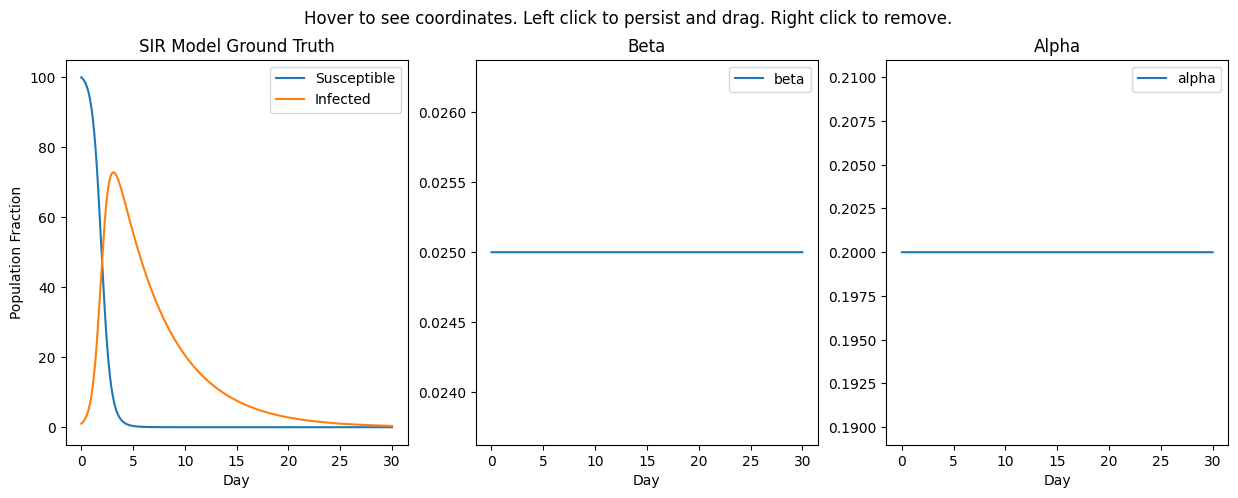

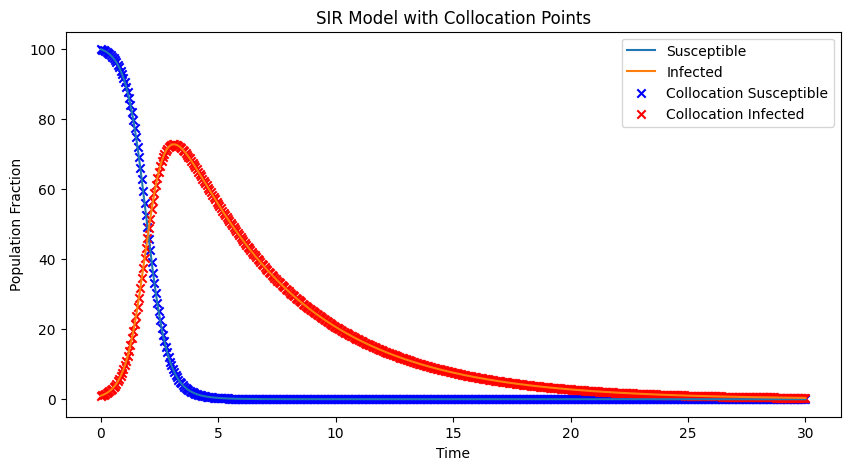

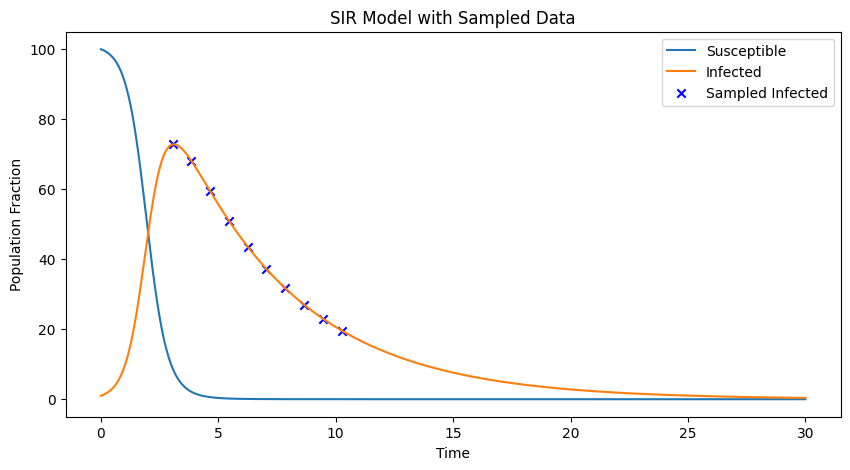

In [9]:
root = 'C:\\cabbage-leaves'

data = SIRModel(0.025, 0.2, 0, 30)
s = np.linspace(610, 2050, 10, dtype=int)
data.set_samples(strategy=s, I_only=True)
data.set_collocation_points(500)
data.plot_ground_truth(interactive=False)
data.plot_with_collocations(interactive=False)
data.plot_with_samples(interactive=False)

### NN model setting

In [10]:
network = Model([1, 64 ,2]).to(device)
optimizer = optim.Adam(network.parameters(), lr=1e-3)

### Experiment config

In [11]:
init_w = np.ones(20001)
data_w = np.ones(20001)
ge_w = np.ones(20001)

ex = Experiment(data, network, optimizer, device, exercise_path=root, n_epochs=20000)
ex.train_model(visualize=True, loss_weights=(init_w, data_w, ge_w))

C:\Users\jinik\AppData\Local\Temp\ipykernel_8844\2519548115.py:60: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3687.)
  y_data = torch.Tensor(self.SIRModel.get_samples()[1]).T.to(device)


GIF saved at C:\cabbage-leaves/png/20250306113530751516/output.gif
Training Finished.


### show result

     Parameter                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     Value
     SIR Model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

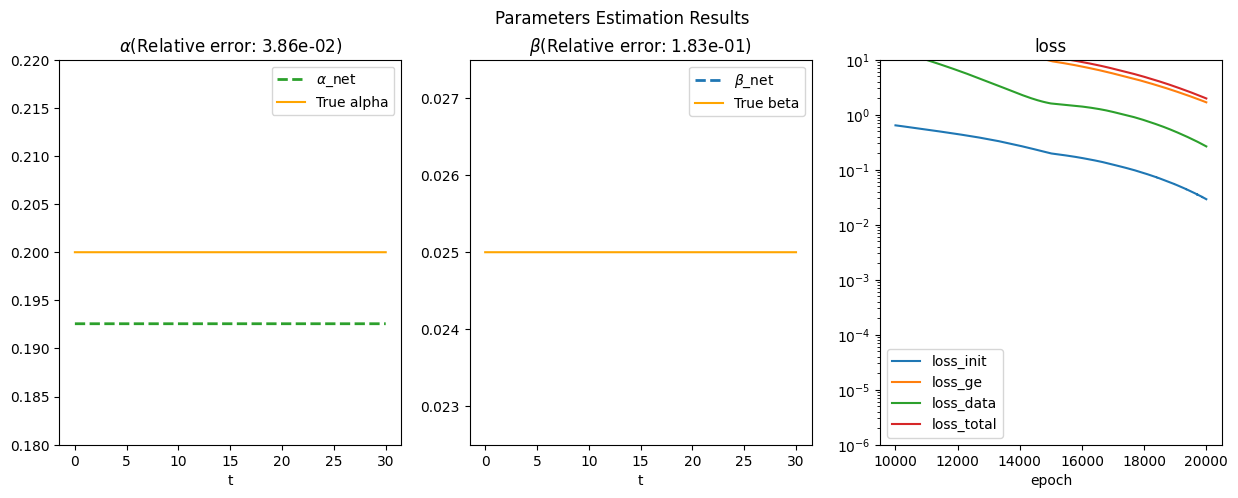

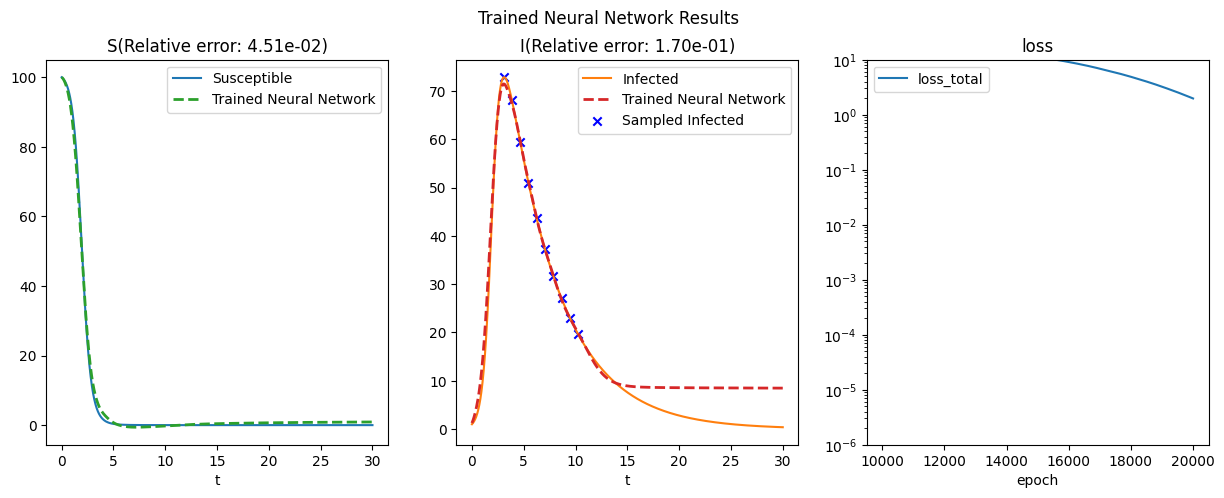

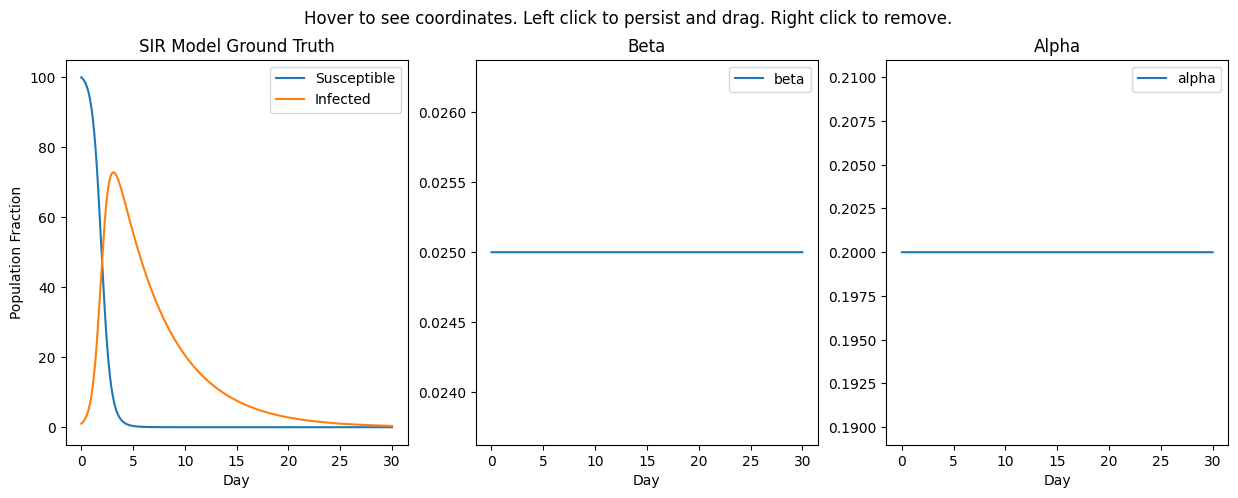

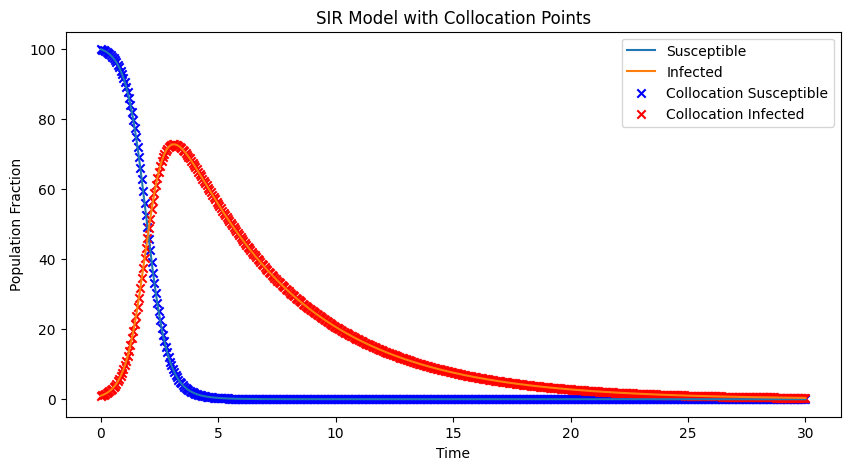

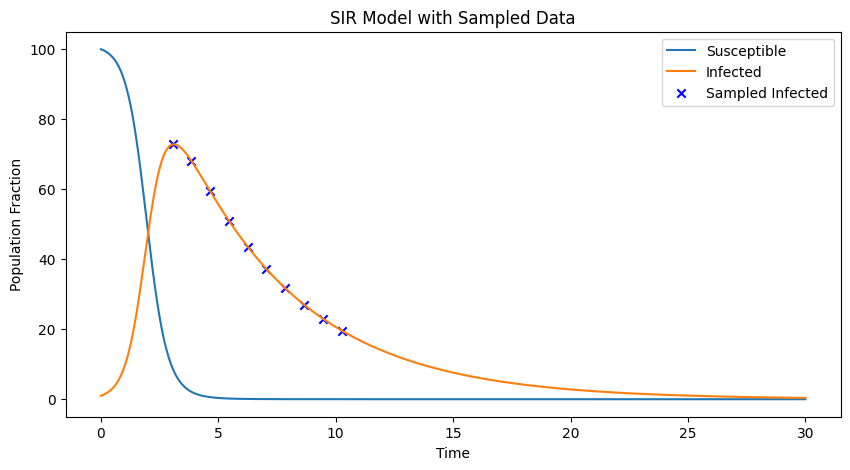

In [12]:
ex.summarize_experiment()
ex.plot_estimated_parameters()
ex.plot_trained_NN()
ex.save_data_image()

## Experiment 1

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\jinik\AppData\Local\Temp\ipykernel_19268\121190550.py:1: SyntaxWarning: invalid escape sequence '\c'
  root = 'C:\cabbage-leaves'


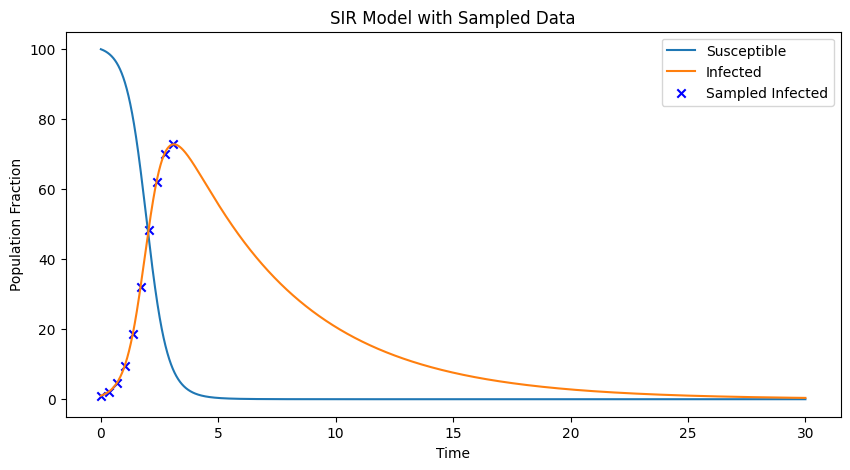

C:\Users\jinik\AppData\Local\Temp\ipykernel_19268\2895763818.py:60: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3687.)
  y_data = torch.Tensor(self.SIRModel.get_samples()[1]).T.to(device)


GIF saved at C:\cabbage-leaves/png/20250305085418571688/output.gif
Training Finished.
     Parameter             Value
     SIR Model          SIRModel
Neural Network             model
     Optimizer              Adam
 Learning Rate          0.000063
     Scheduler            StepLR
        Device               cpu
        Epochs             20000
 Loss Function           MSELoss
 Weight (Init)                 1
 Weight (Data)                 1
   Weight (Ge)                 1
     Save Path C:\cabbage-leaves
 Training Time           0:04:32
beta_pred (6001,)


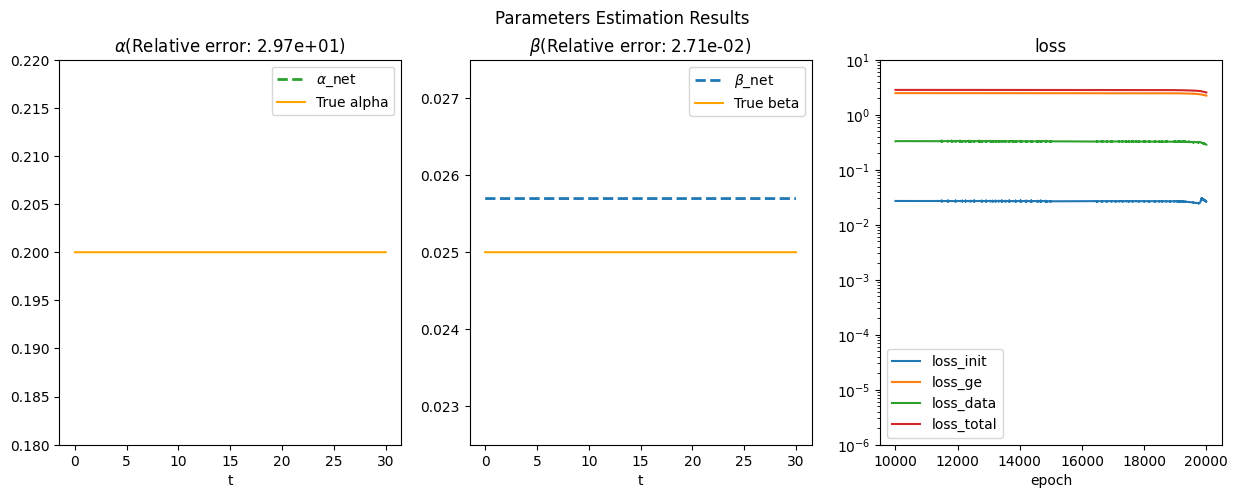

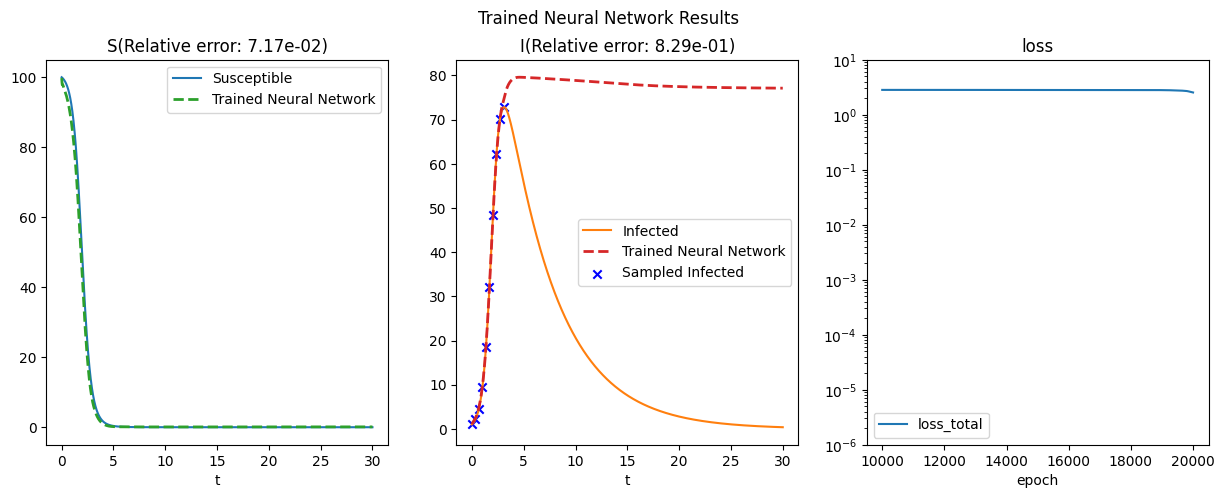

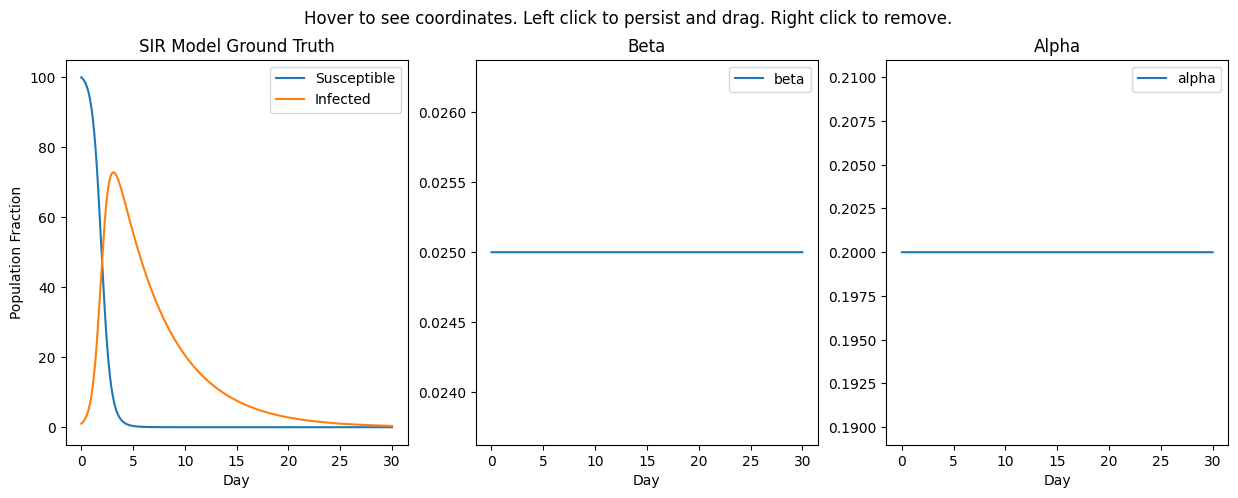

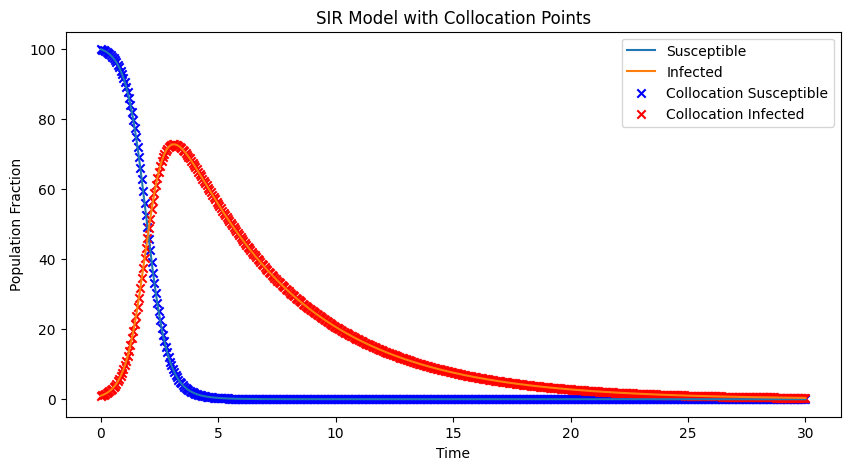

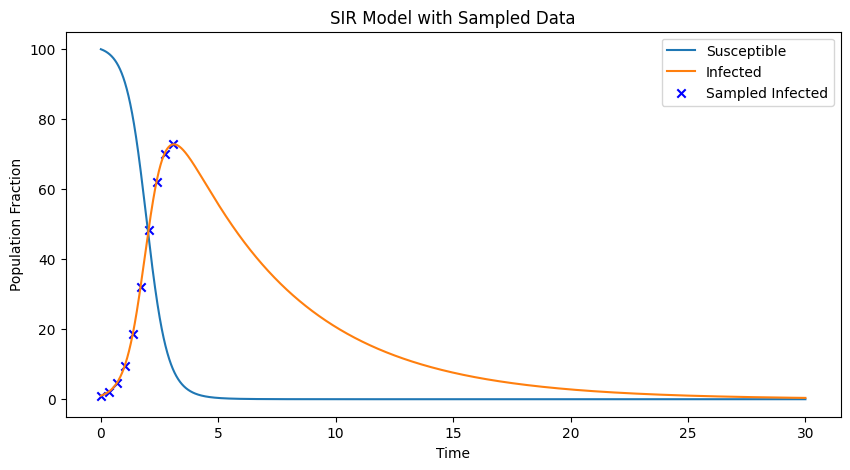

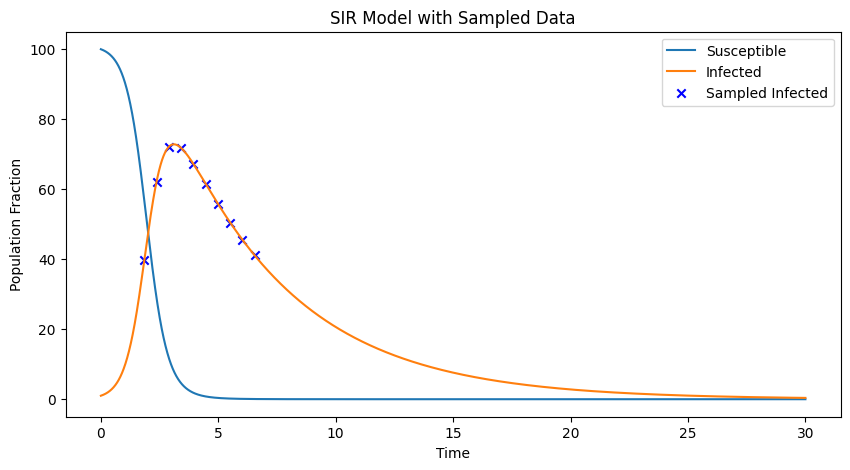

GIF saved at C:\cabbage-leaves/png/20250305085854512947/output.gif
Training Finished.
     Parameter             Value
     SIR Model          SIRModel
Neural Network             model
     Optimizer              Adam
 Learning Rate          0.000063
     Scheduler            StepLR
        Device               cpu
        Epochs             20000
 Loss Function           MSELoss
 Weight (Init)                 1
 Weight (Data)                 1
   Weight (Ge)                 1
     Save Path C:\cabbage-leaves
 Training Time           0:04:19
beta_pred (6001,)


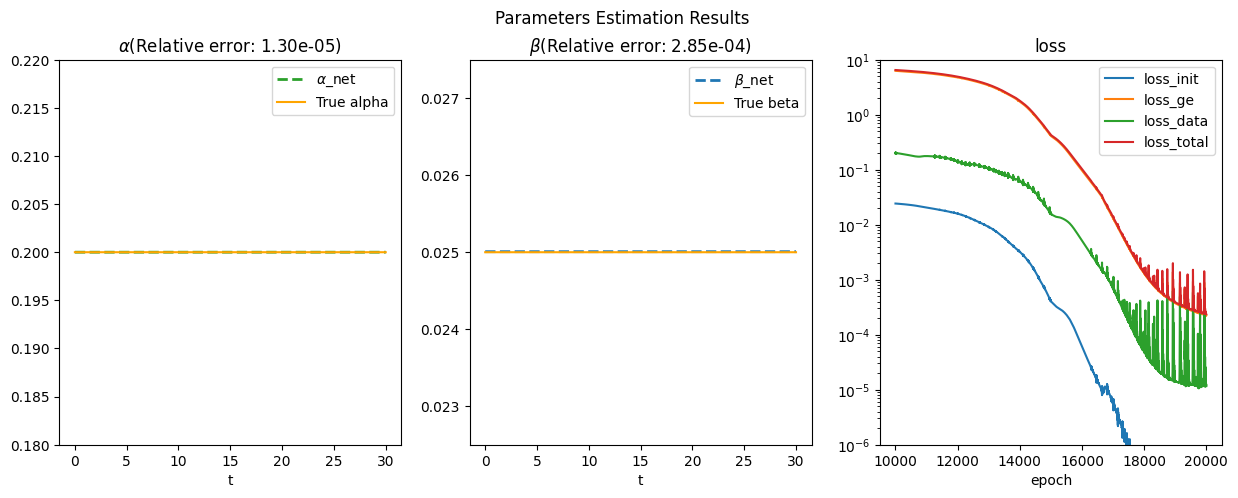

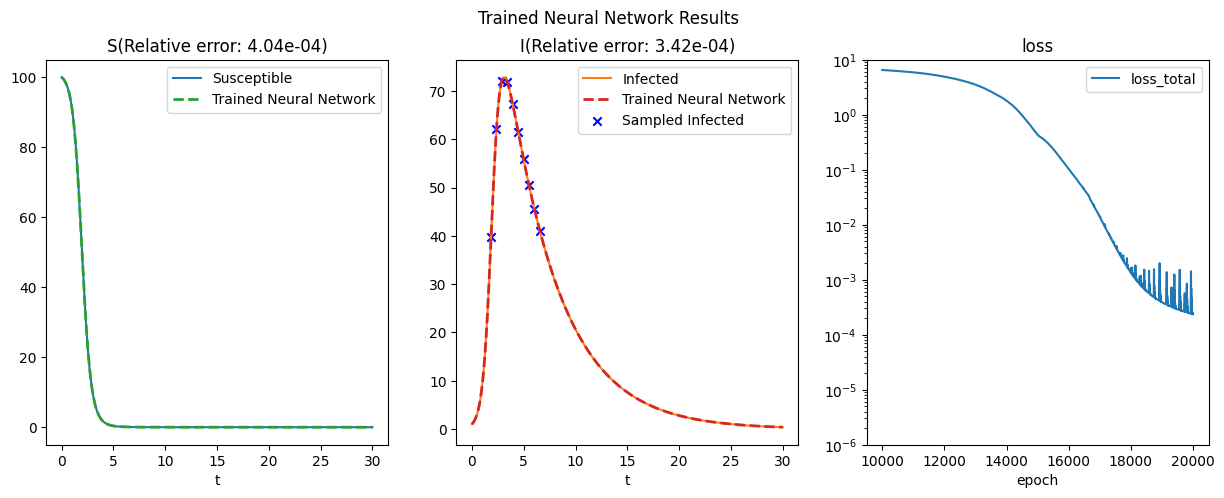

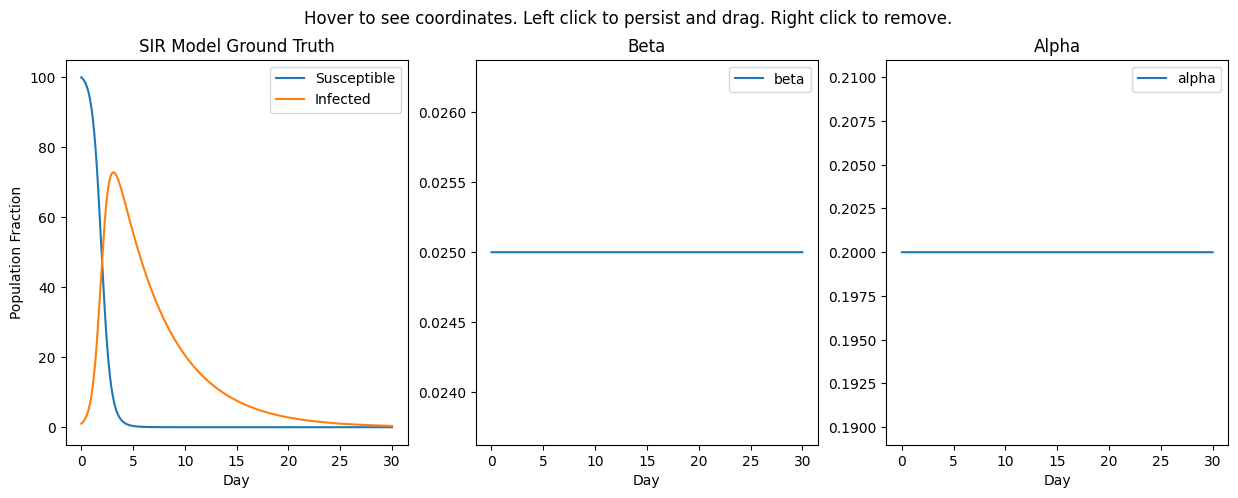

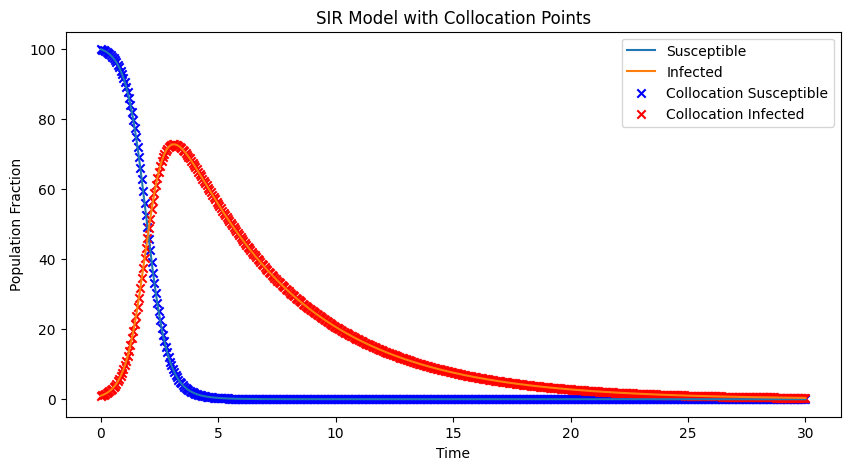

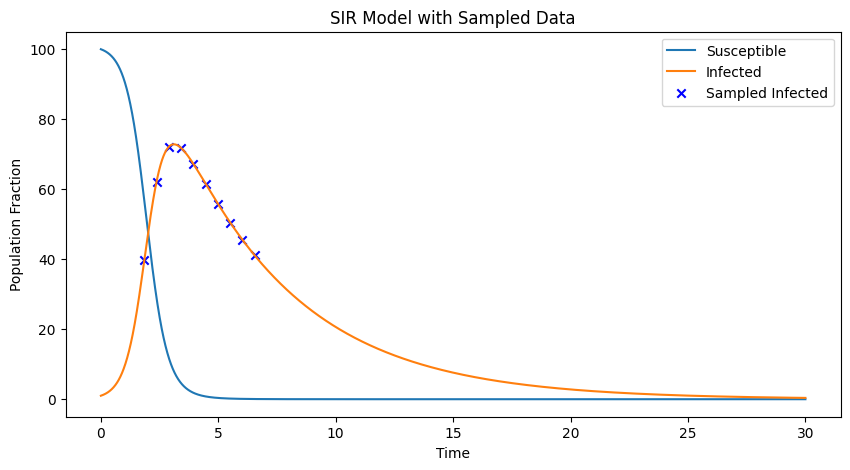

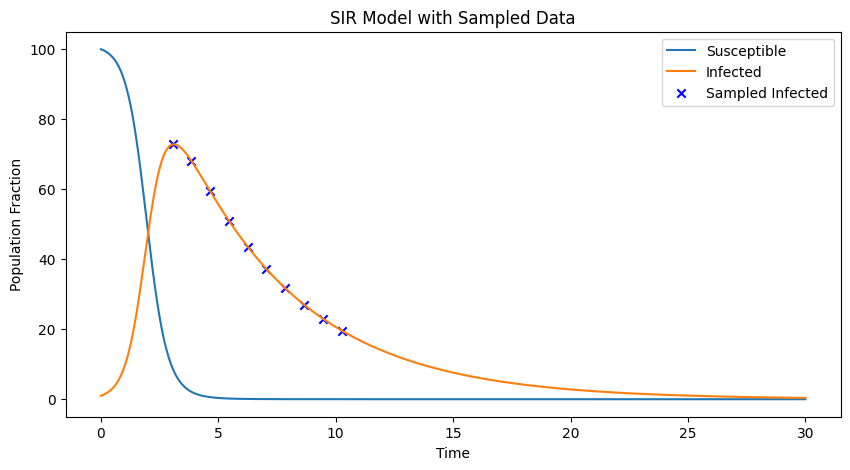

GIF saved at C:\cabbage-leaves/png/20250305090317622085/output.gif
Training Finished.
     Parameter             Value
     SIR Model          SIRModel
Neural Network             model
     Optimizer              Adam
 Learning Rate          0.000063
     Scheduler            StepLR
        Device               cpu
        Epochs             20000
 Loss Function           MSELoss
 Weight (Init)                 1
 Weight (Data)                 1
   Weight (Ge)                 1
     Save Path C:\cabbage-leaves
 Training Time           0:04:09
beta_pred (6001,)


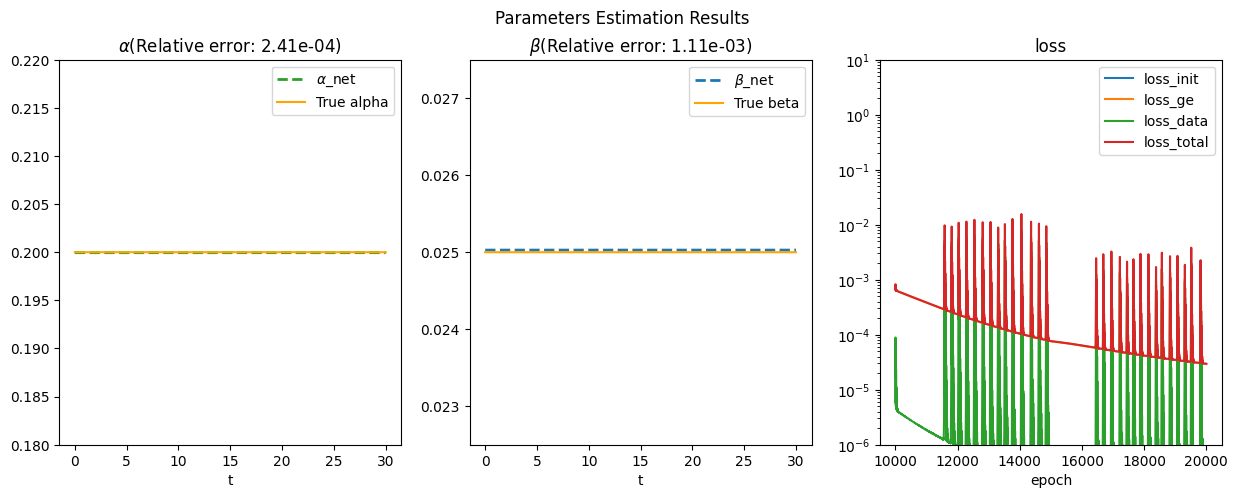

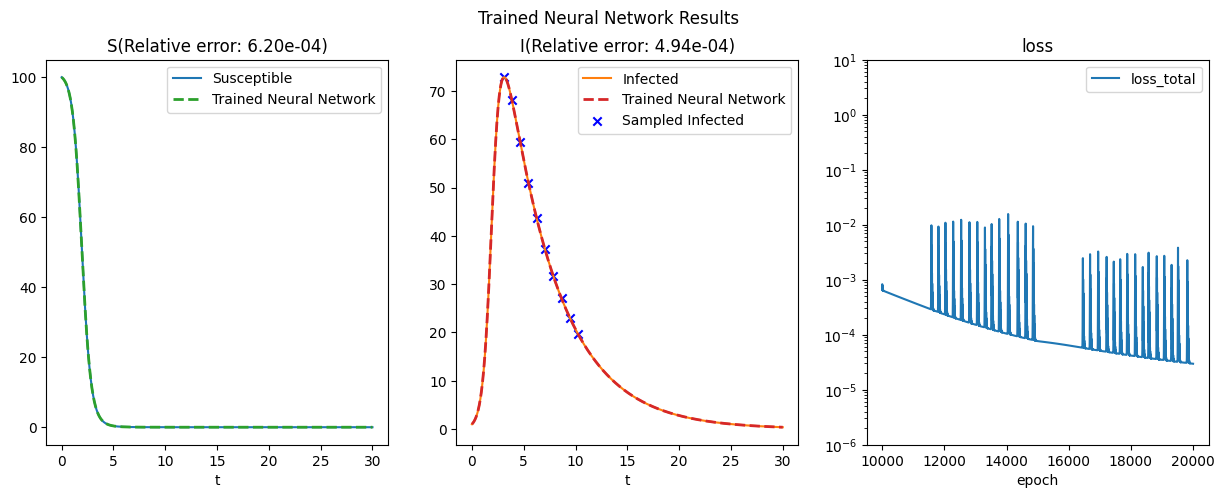

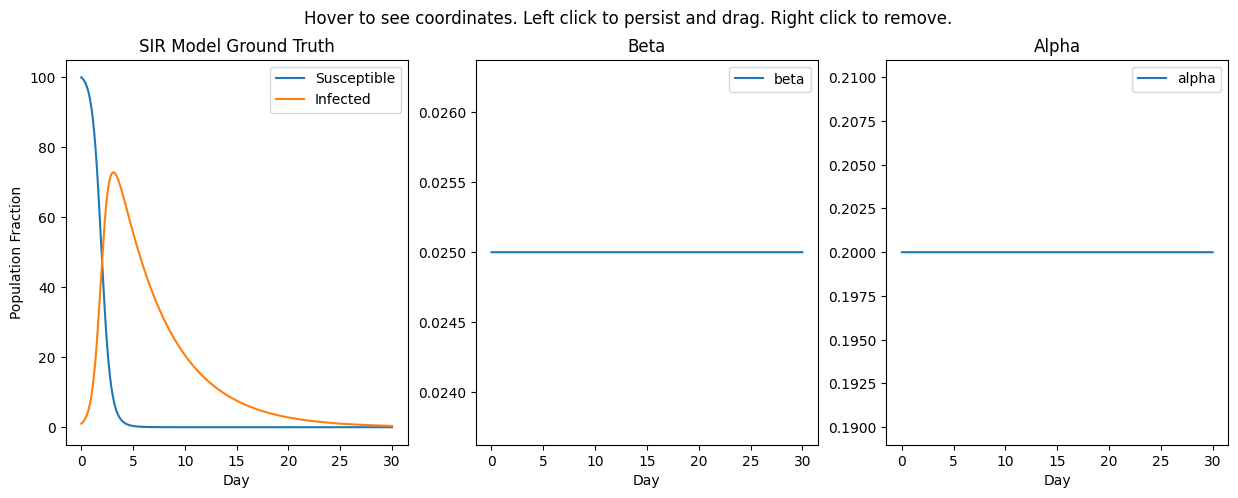

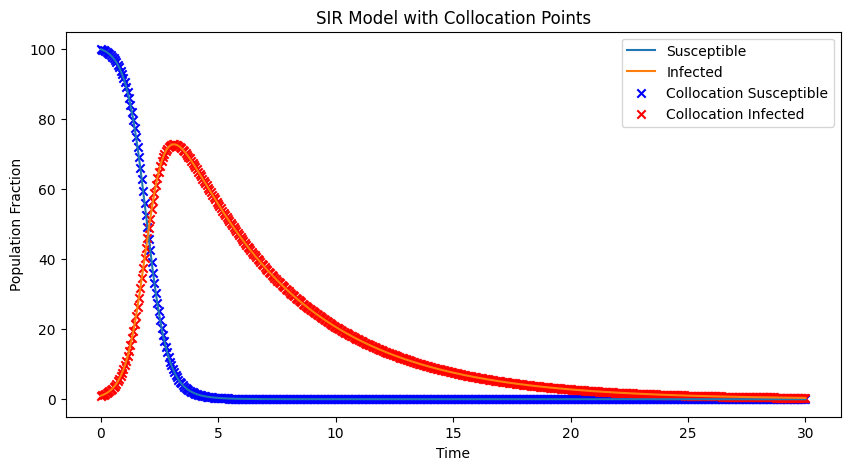

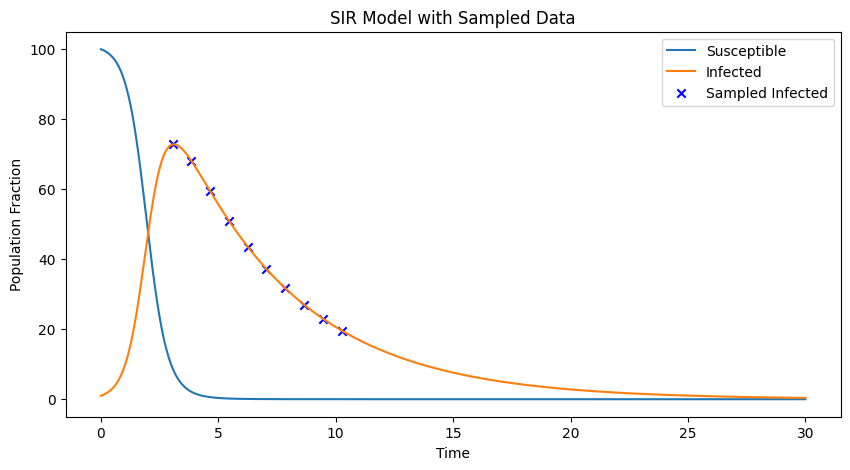

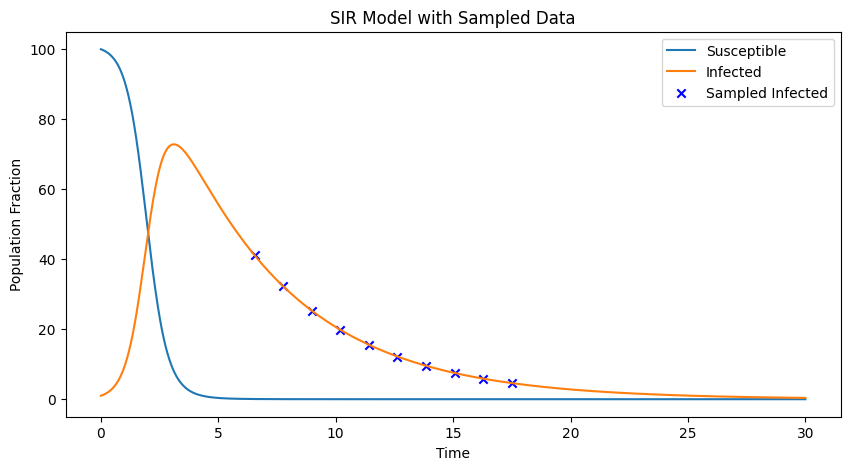

GIF saved at C:\cabbage-leaves/png/20250305090729849037/output.gif
Training Finished.
     Parameter             Value
     SIR Model          SIRModel
Neural Network             model
     Optimizer              Adam
 Learning Rate          0.000063
     Scheduler            StepLR
        Device               cpu
        Epochs             20000
 Loss Function           MSELoss
 Weight (Init)                 1
 Weight (Data)                 1
   Weight (Ge)                 1
     Save Path C:\cabbage-leaves
 Training Time           0:04:28
beta_pred (6001,)


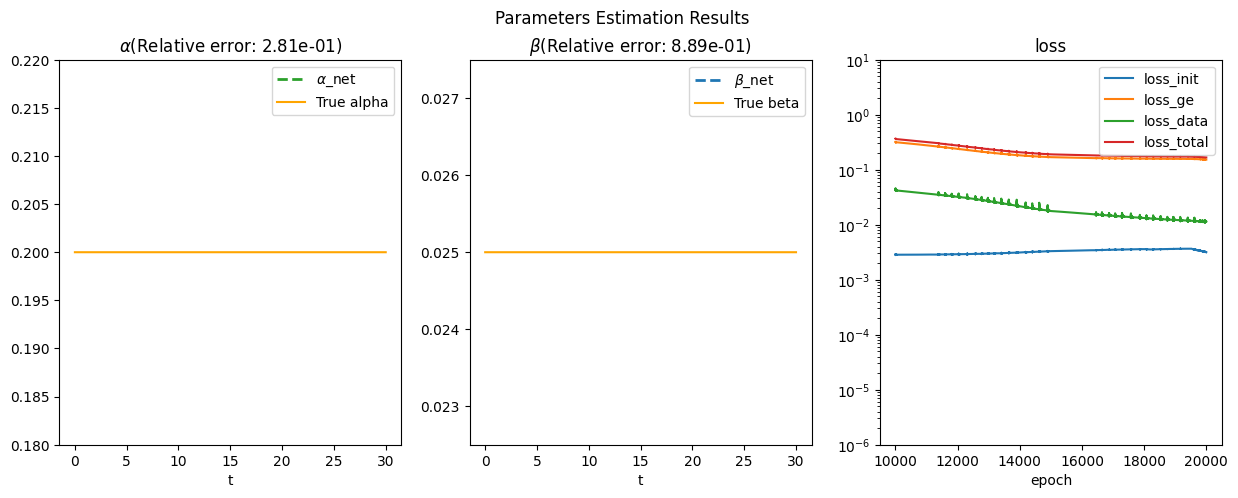

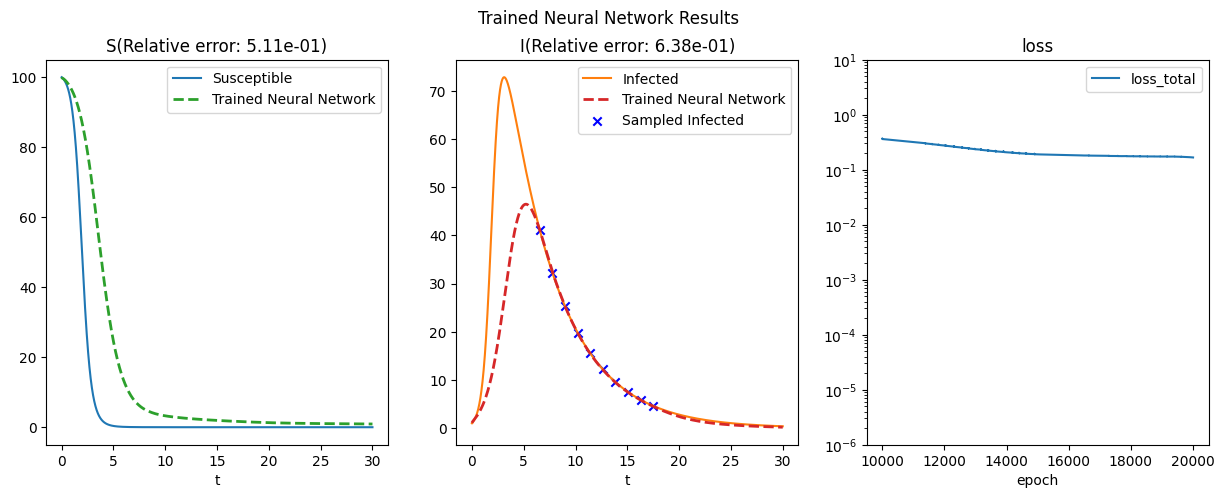

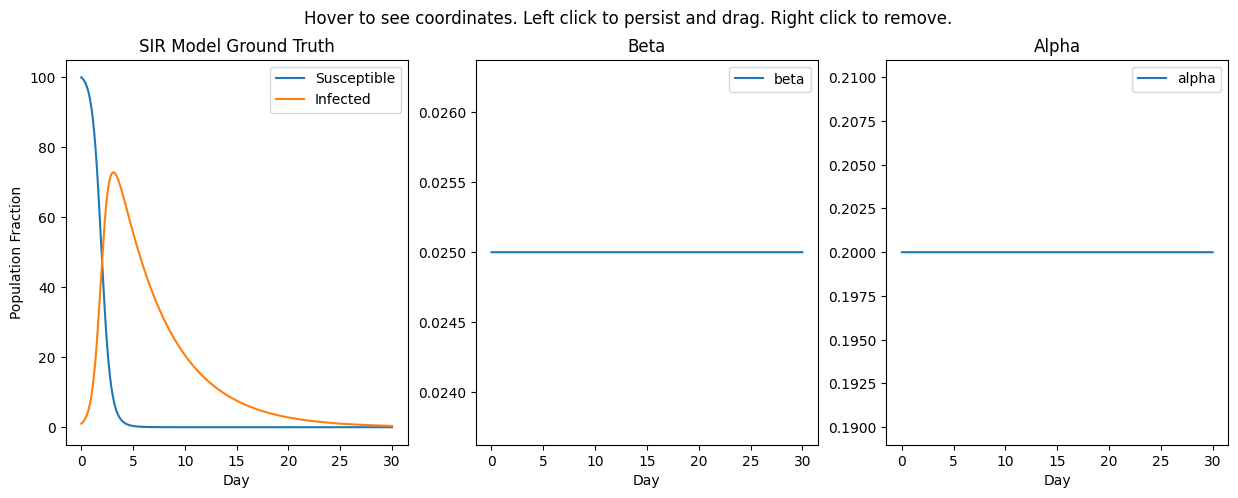

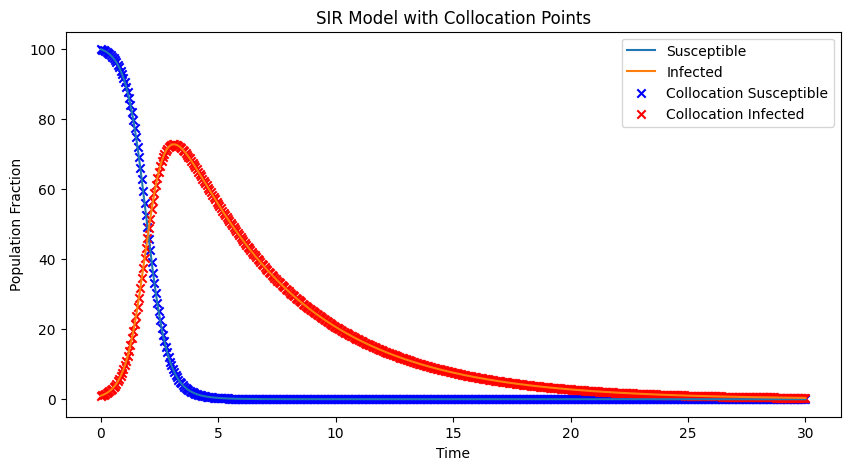

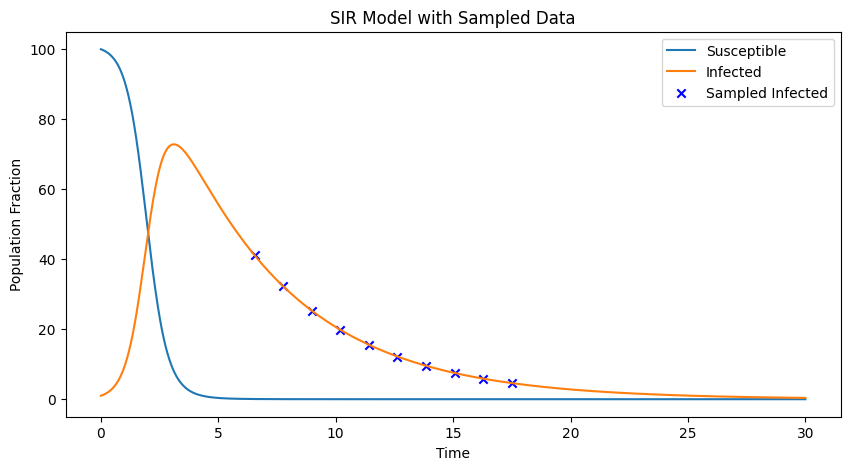

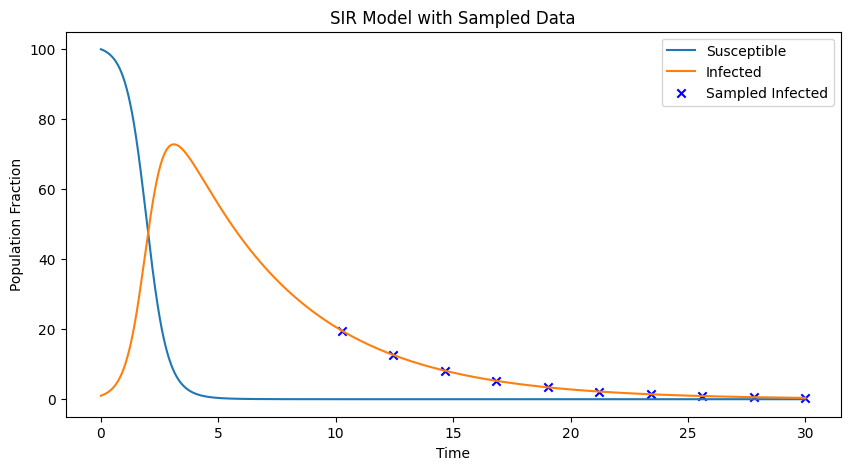

GIF saved at C:\cabbage-leaves/png/20250305091201560548/output.gif
Training Finished.
     Parameter             Value
     SIR Model          SIRModel
Neural Network             model
     Optimizer              Adam
 Learning Rate          0.000063
     Scheduler            StepLR
        Device               cpu
        Epochs             20000
 Loss Function           MSELoss
 Weight (Init)                 1
 Weight (Data)                 1
   Weight (Ge)                 1
     Save Path C:\cabbage-leaves
 Training Time           0:04:27
beta_pred (6001,)


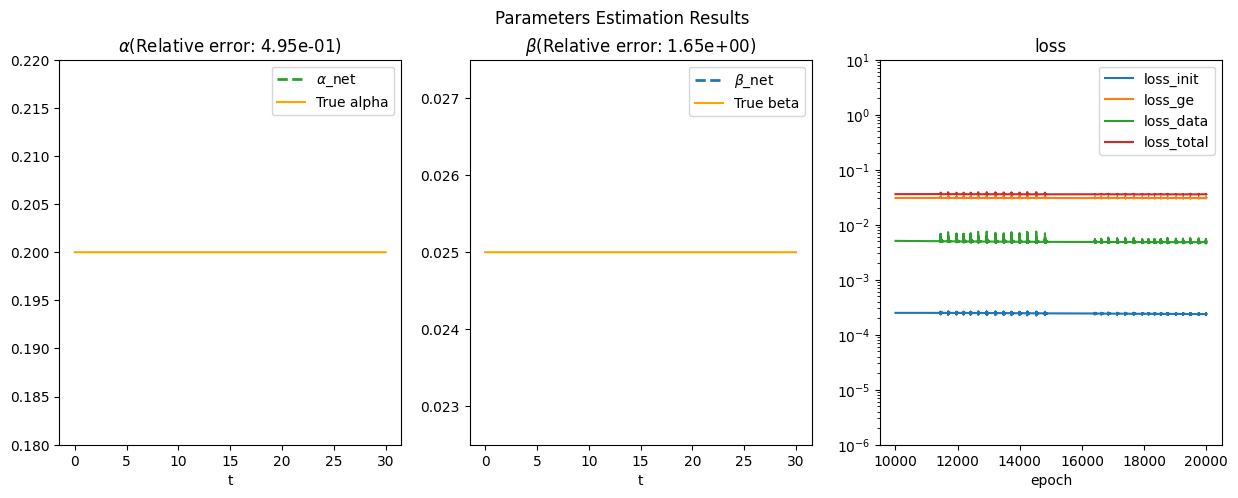

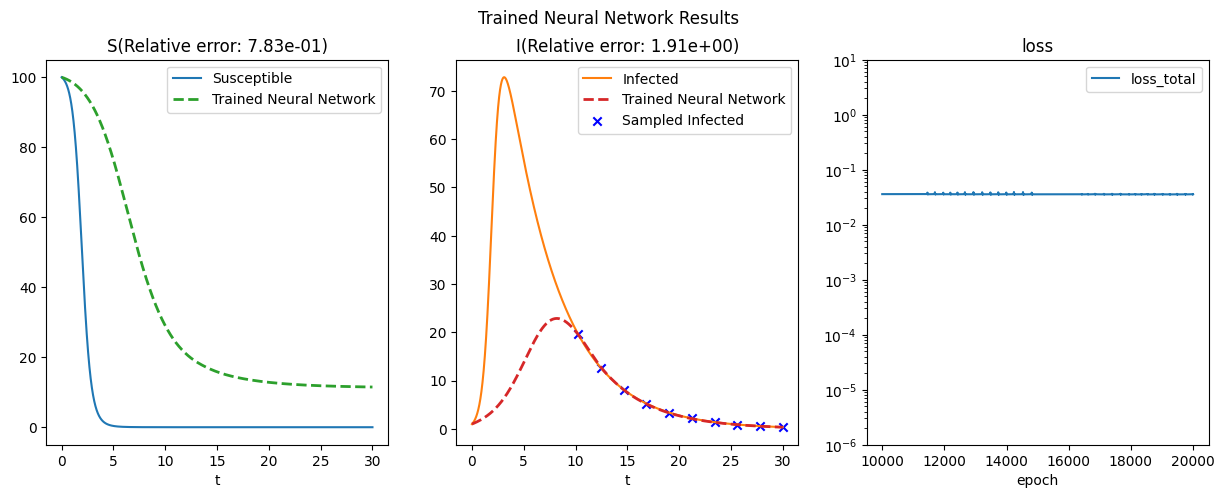

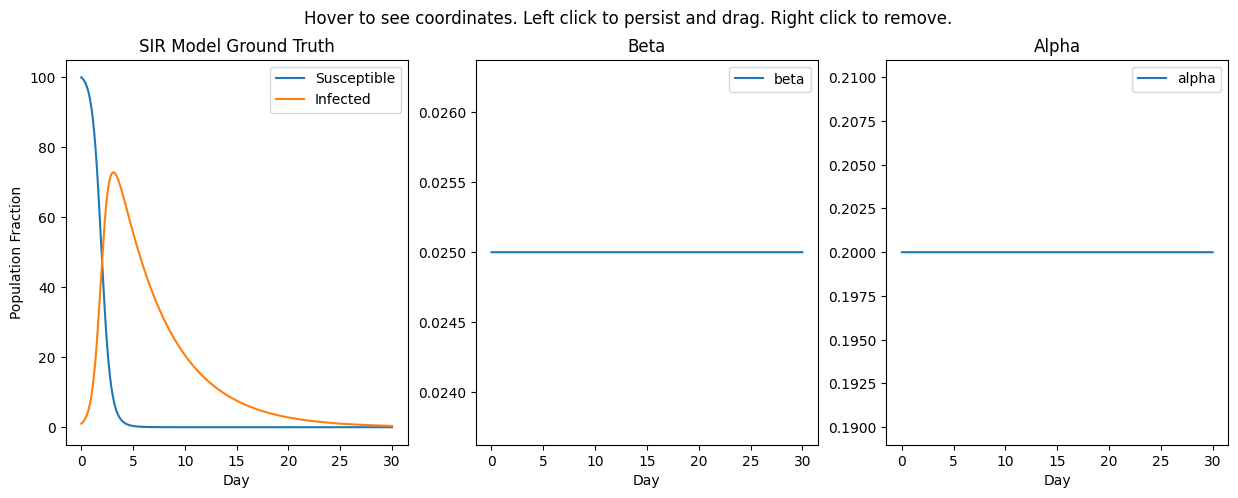

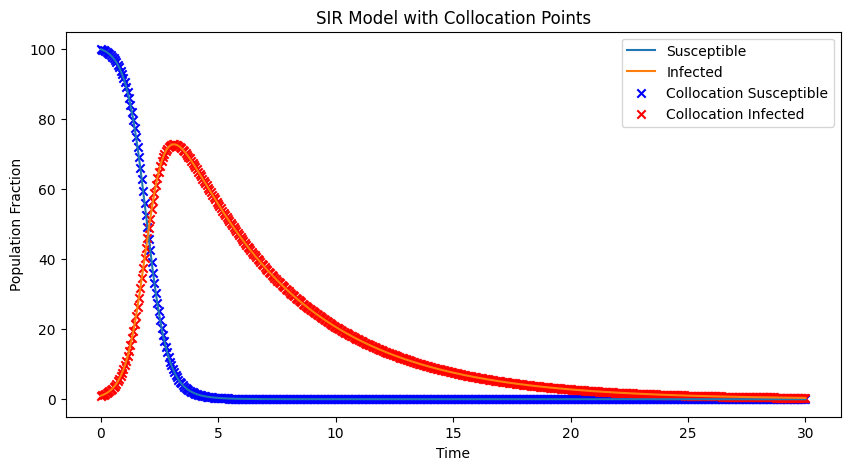

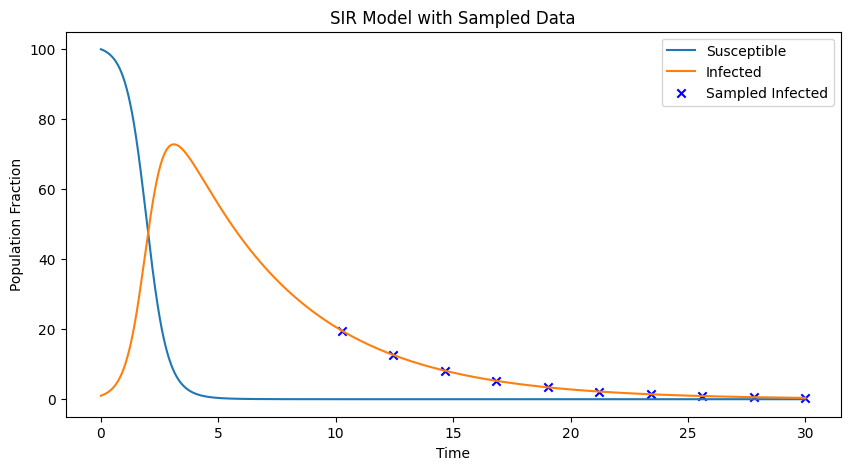

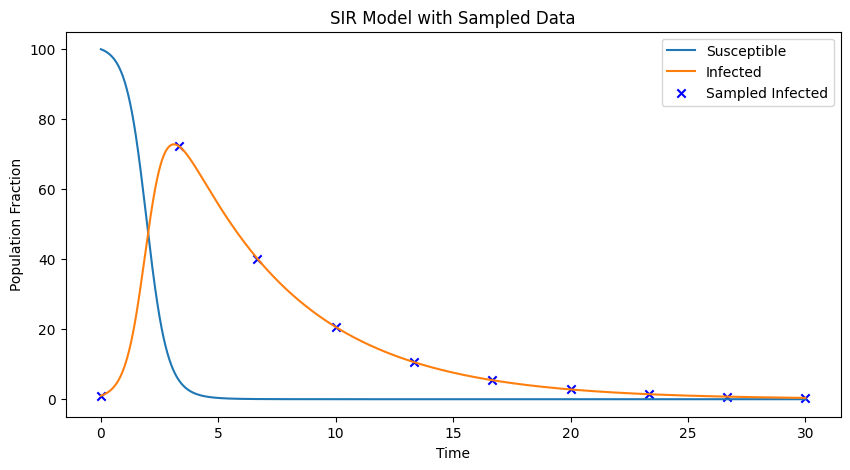

GIF saved at C:\cabbage-leaves/png/20250305091632038840/output.gif
Training Finished.
     Parameter             Value
     SIR Model          SIRModel
Neural Network             model
     Optimizer              Adam
 Learning Rate          0.000063
     Scheduler            StepLR
        Device               cpu
        Epochs             20000
 Loss Function           MSELoss
 Weight (Init)                 1
 Weight (Data)                 1
   Weight (Ge)                 1
     Save Path C:\cabbage-leaves
 Training Time           0:04:17
beta_pred (6001,)


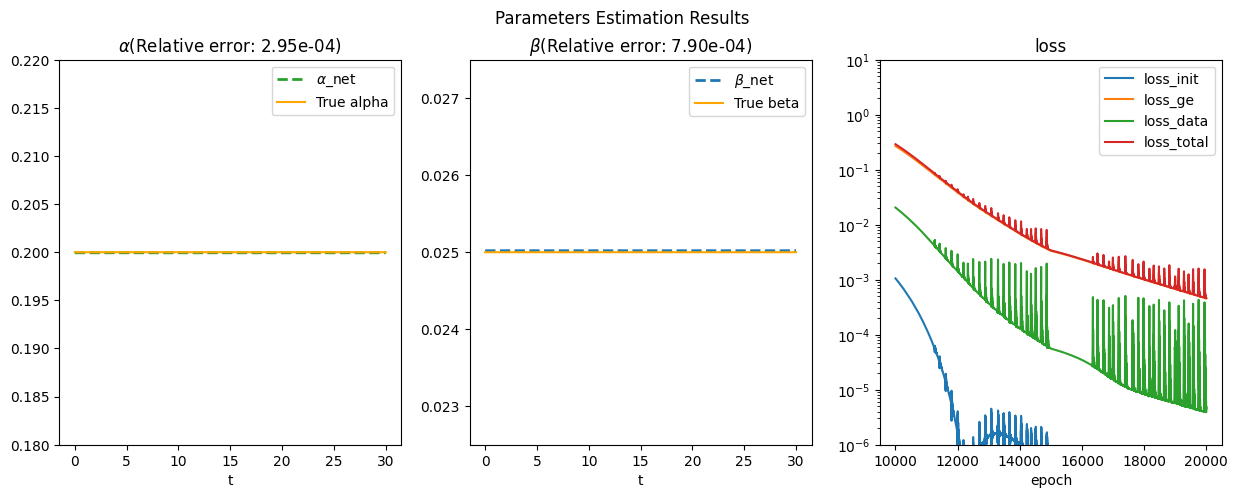

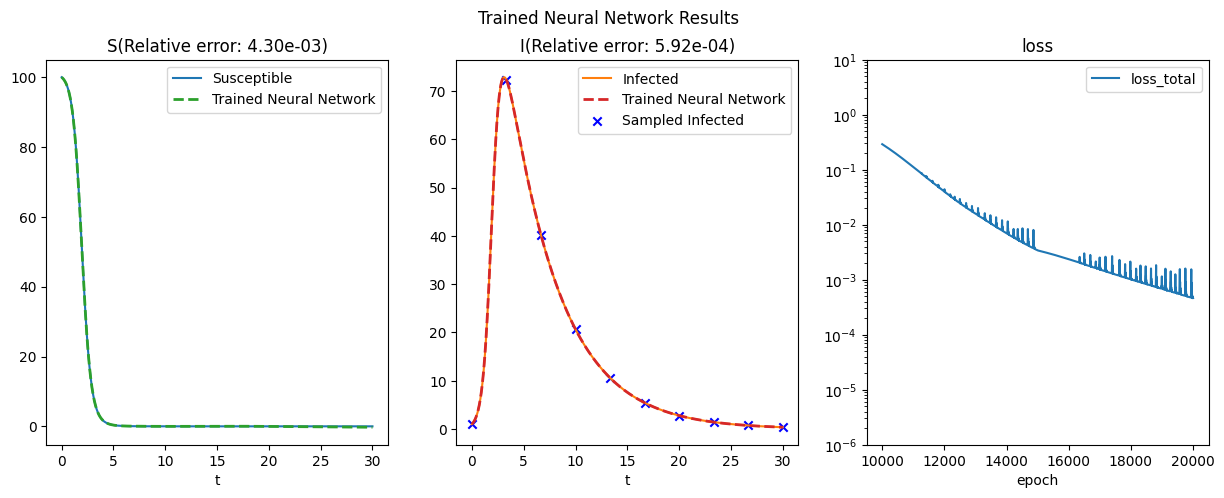

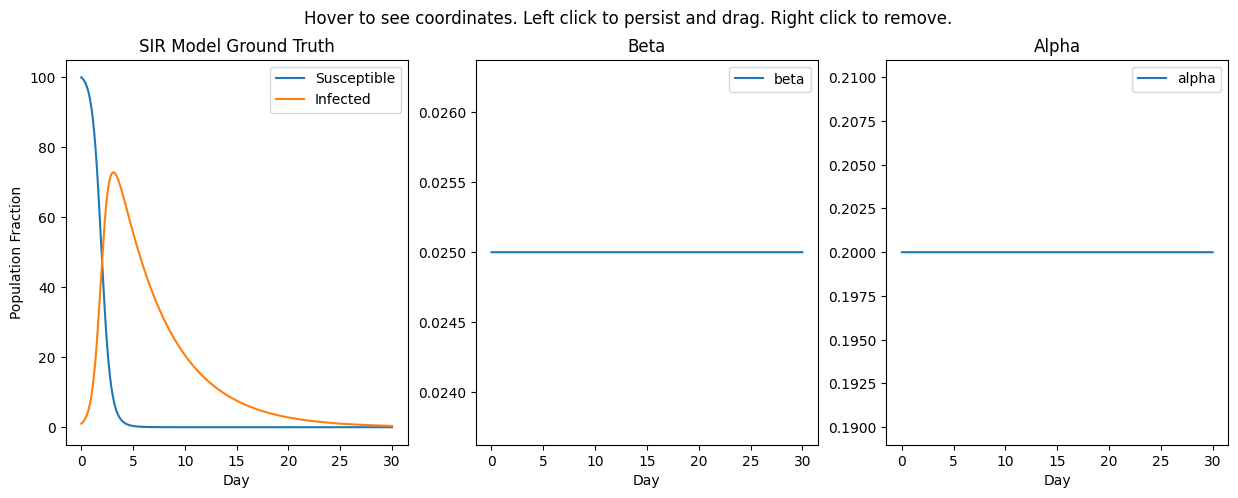

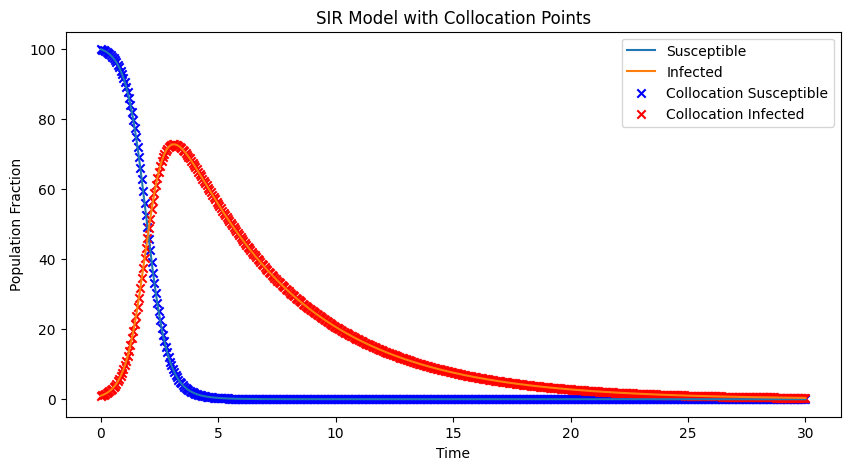

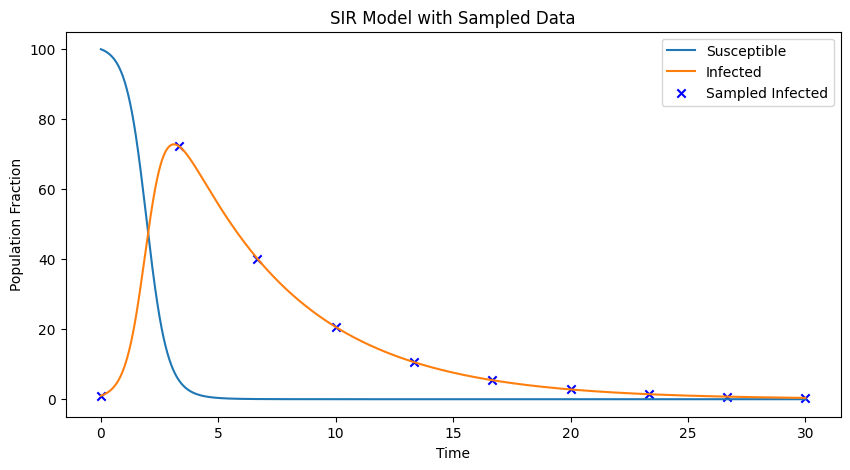

In [69]:
root = 'C:\cabbage-leaves'

data = SIRModel(0.025, 0.2, 0, 30)
strategy = [
    np.linspace(0, 610, 10, dtype=int),
    np.linspace(370, 1310, 10, dtype=int),
    np.linspace(610, 2050, 10, dtype=int),
    np.linspace(1310, 3500, 10, dtype=int),
    np.linspace(2050, len(data.get_whole_t())-1, 10, dtype=int),
    np.linspace(0, len(data.get_whole_t())-1, 10, dtype=int)
]

for s in strategy:
    data.set_samples(strategy=s, I_only=True)
    data.set_collocation_points(500)
    data.plot_with_samples()

    network = model([1,64,64,64,2]).to(device)
    optimizer = optim.Adam(network.parameters(), lr=1e-3)

    ex = Experiment(data, network, optimizer, device, exercise_path=root)
    ex.train_model(visualize=True)

    ex.summarize_experiment()
    ex.plot_estimated_parameters()
    ex.plot_trained_NN()
    ex.save_data_image()
    ex.get_serial_folder_name()

## Experiment 2

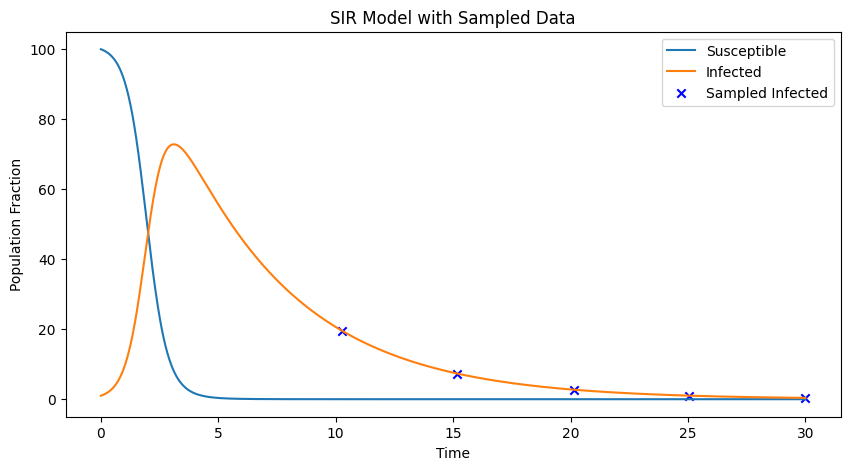

GIF saved at C:\cabbage-leaves/png/20250306110138973456/output.gif
Training Finished.
     Parameter                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     Value
     SIR Model                                                                                                                                                                                                                                                                                                                                                                                           

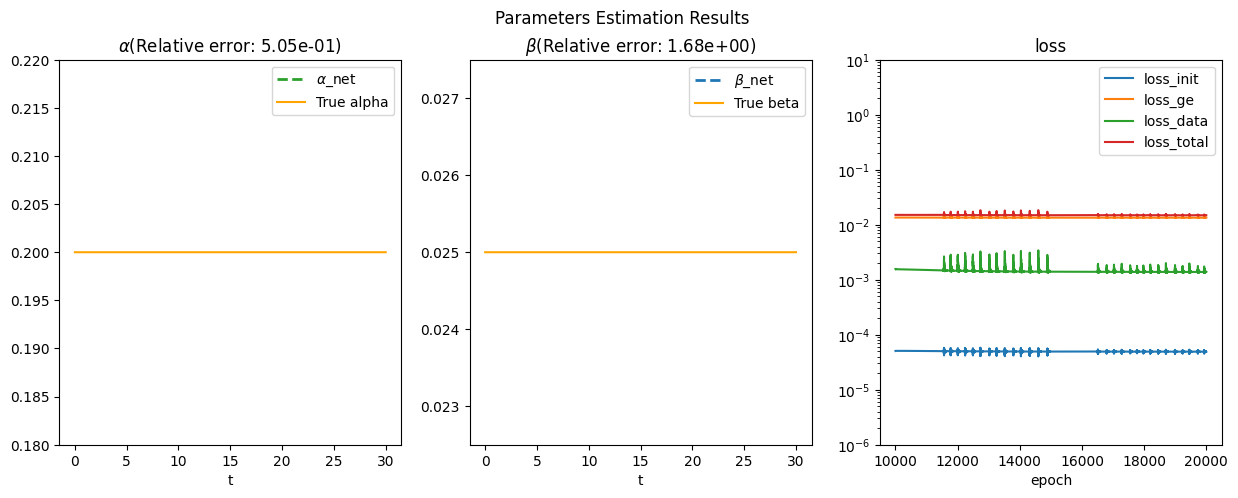

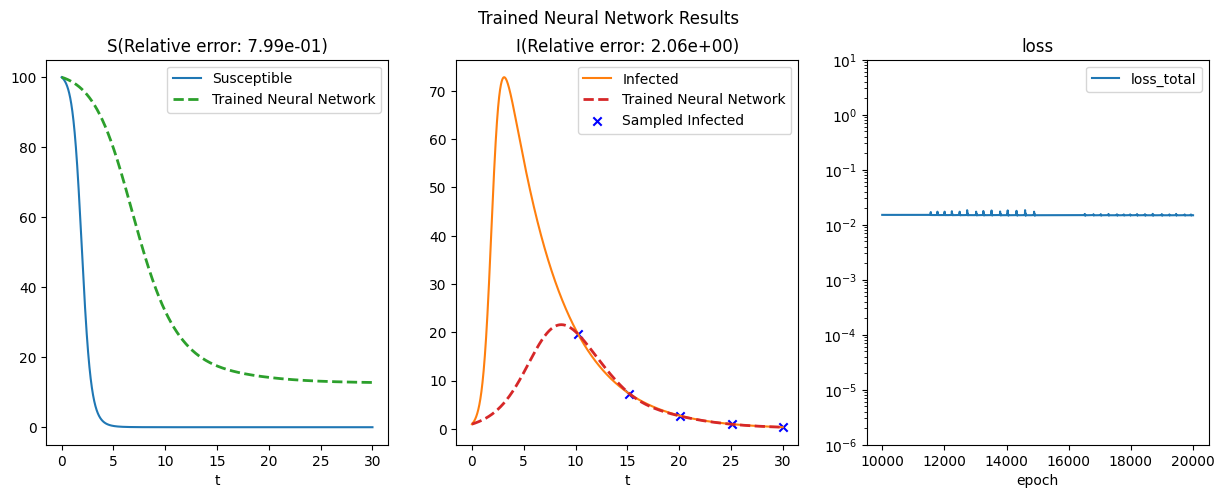

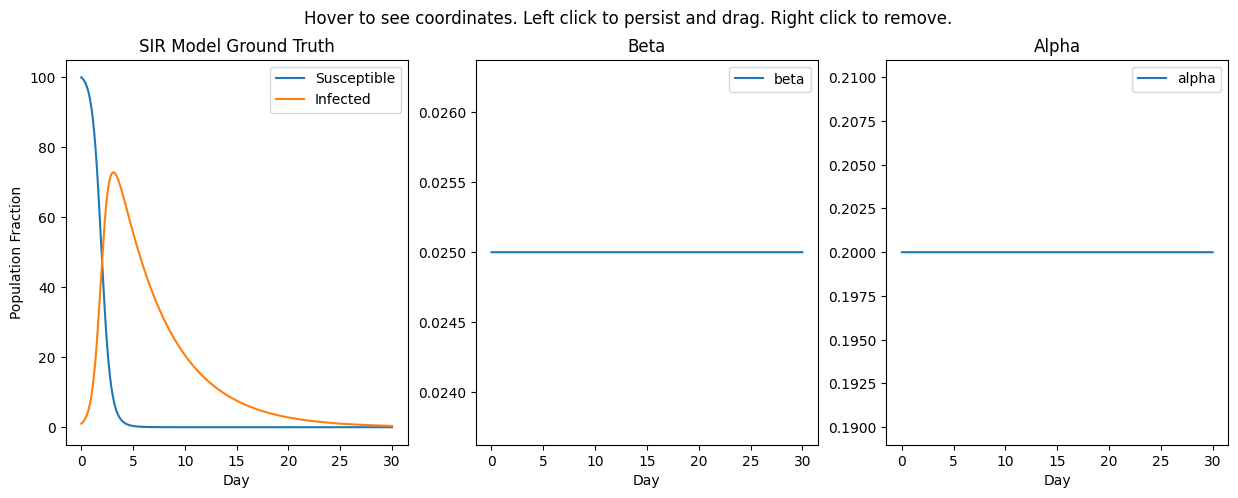

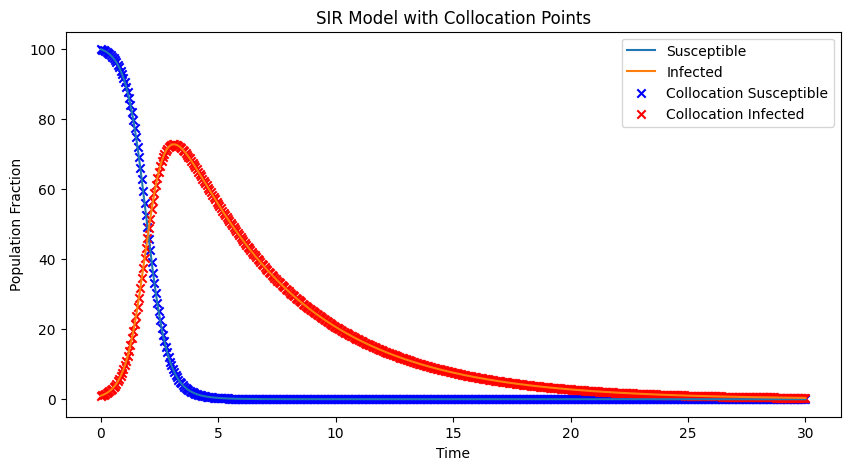

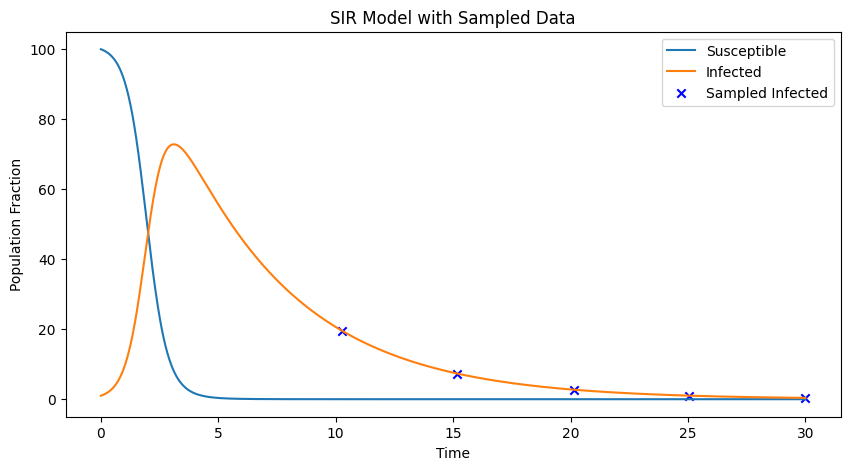

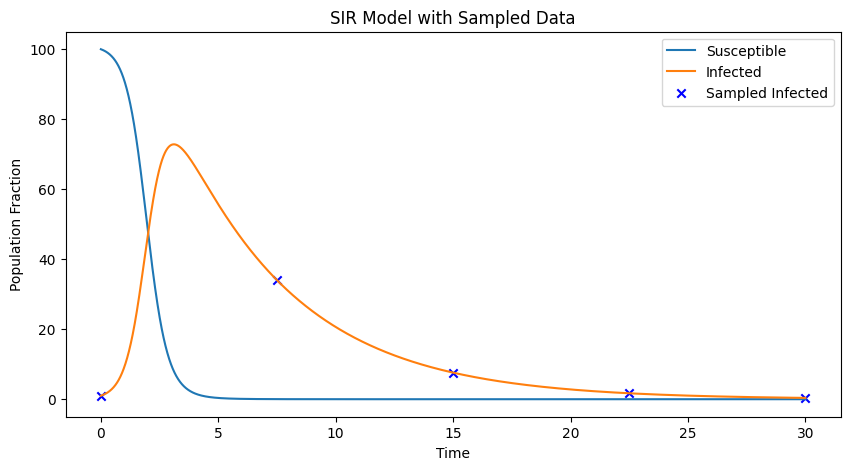

GIF saved at C:\cabbage-leaves/png/20250306110617640546/output.gif
Training Finished.
     Parameter                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     Value
     SIR Model                                                                                                                                                                                                                                                                                                                                                                                           

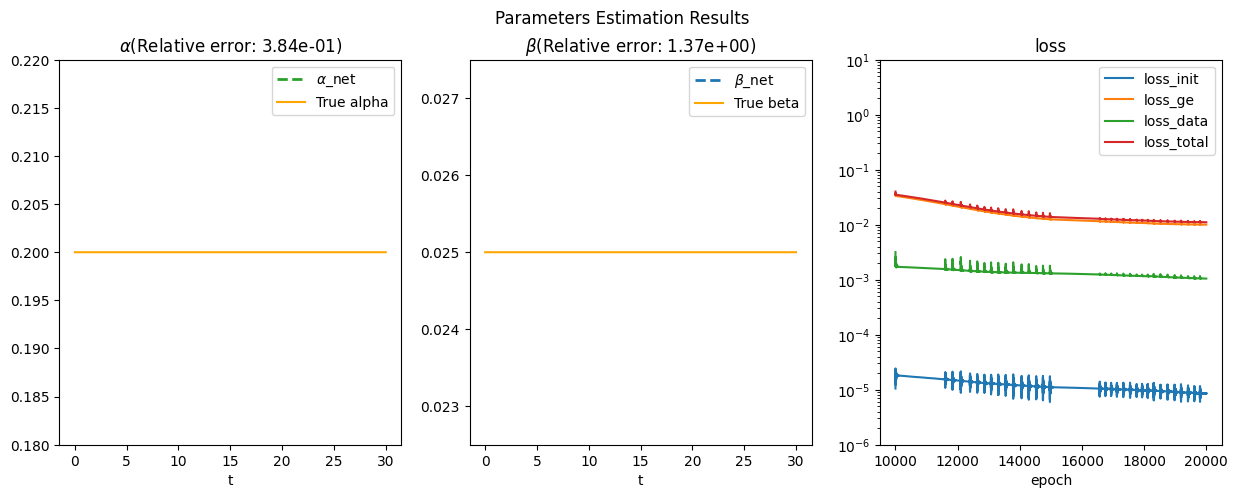

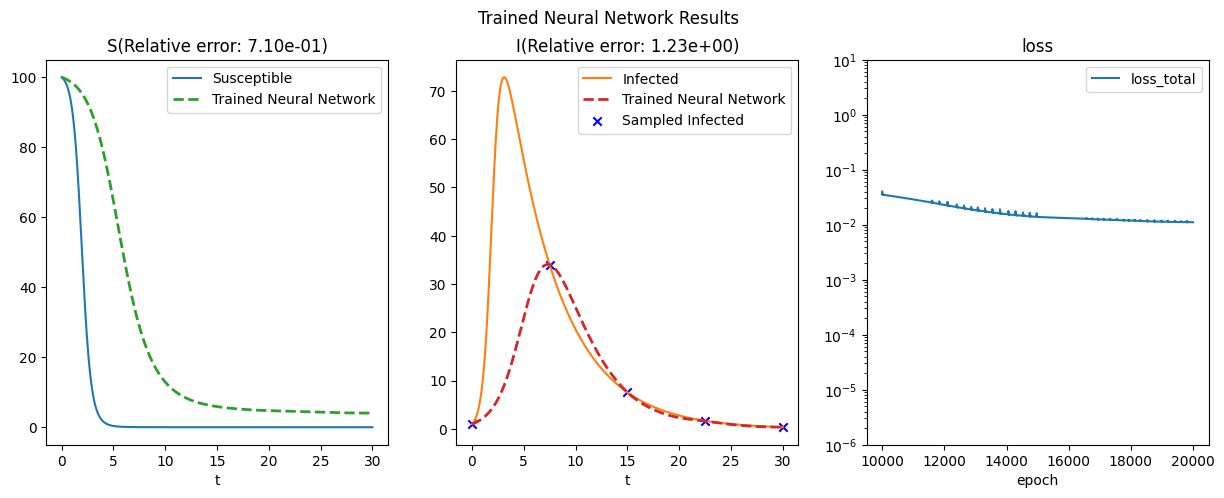

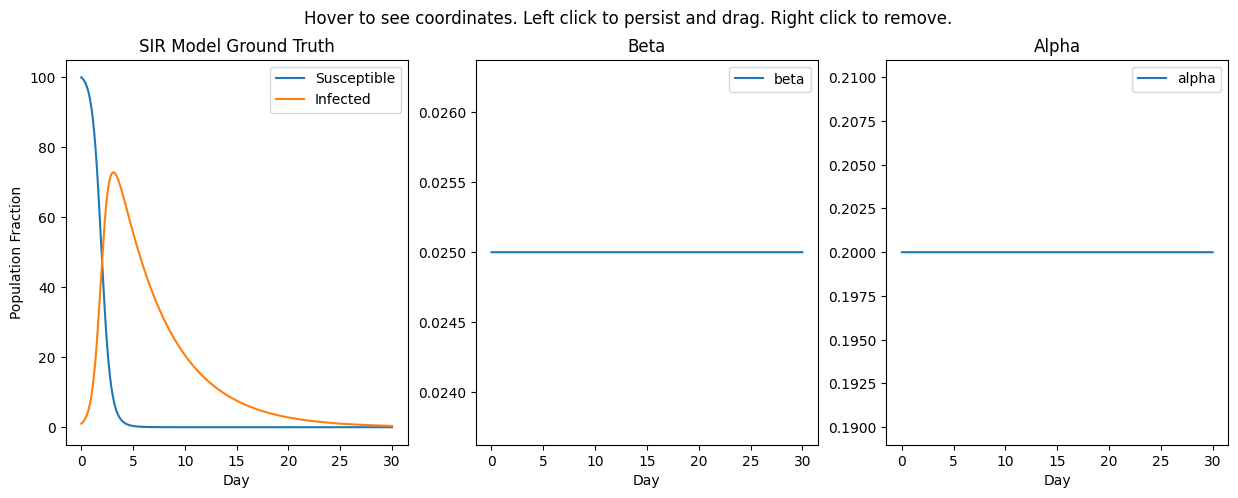

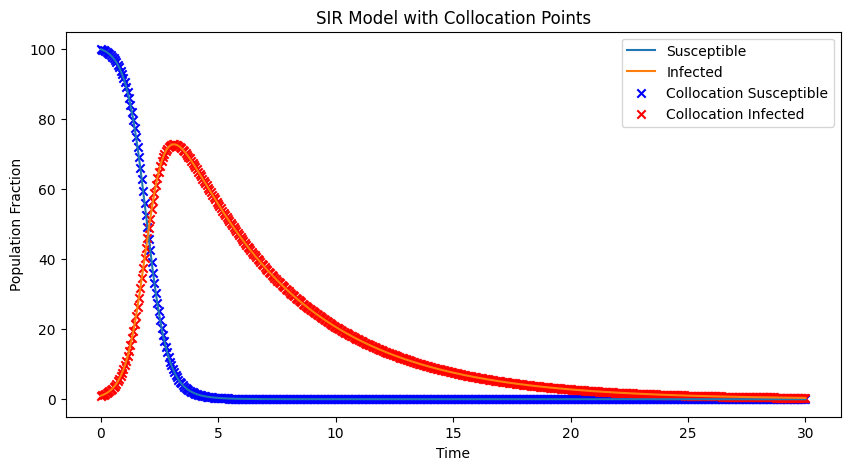

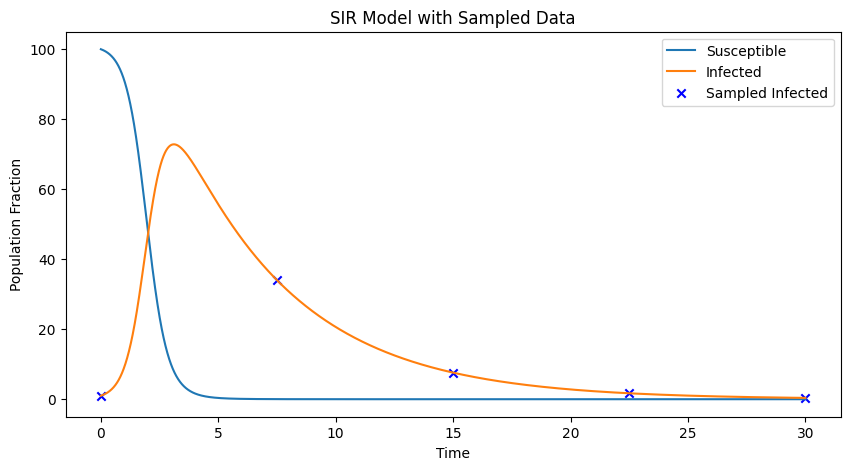

In [17]:
root = 'C:\\cabbage-leaves'

data = SIRModel(0.025, 0.2, 0, 30)
strategy = [
    # np.linspace(0, 610, 5, dtype=int),
    # np.linspace(370, 1310, 5, dtype=int),
    # np.linspace(610, 2050, 5, dtype=int),
    # np.linspace(1310, 3500, 5, dtype=int),
    np.linspace(2050, len(data.get_whole_t())-1, 5, dtype=int),
    np.linspace(0, len(data.get_whole_t())-1, 5, dtype=int)
]

init_w = np.ones(20001)
data_w = np.ones(20001)
ge_w = np.ones(20001)

for s in strategy:
    data.set_samples(strategy=s, I_only=True)
    data.set_collocation_points(500)
    data.plot_with_samples()

    network = Model([1,64,64,64,2]).to(device)
    optimizer = optim.Adam(network.parameters(), lr=1e-3)

    ex = Experiment(data, network, optimizer, device, exercise_path=root)
    ex.train_model(visualize=True, loss_weights=(init_w, data_w, ge_w))

    ex.summarize_experiment()
    ex.plot_estimated_parameters()
    ex.plot_trained_NN()
    ex.save_data_image()
    ex.get_serial_folder_name()

## Experiment 3

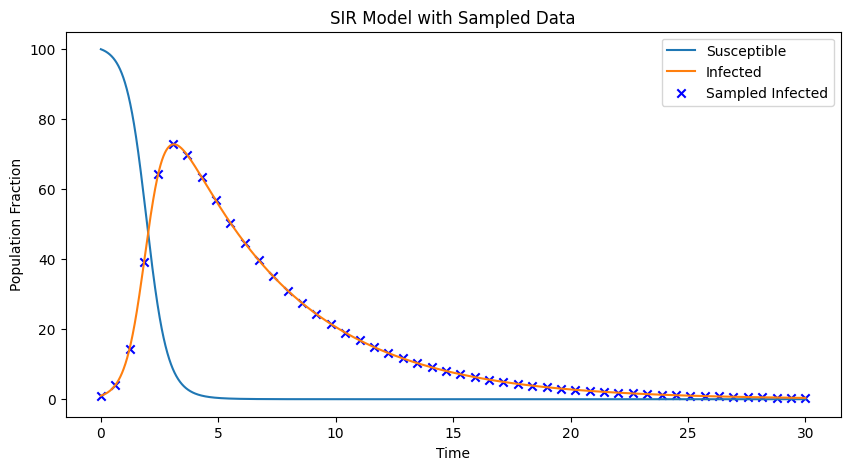

GIF saved at C:\cabbage-leaves/png/20250306005920502599/output.gif
Training Finished.
     Parameter                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     Value
     SIR Model                                                                                                                                                                                                                                                                                                                                                                                           

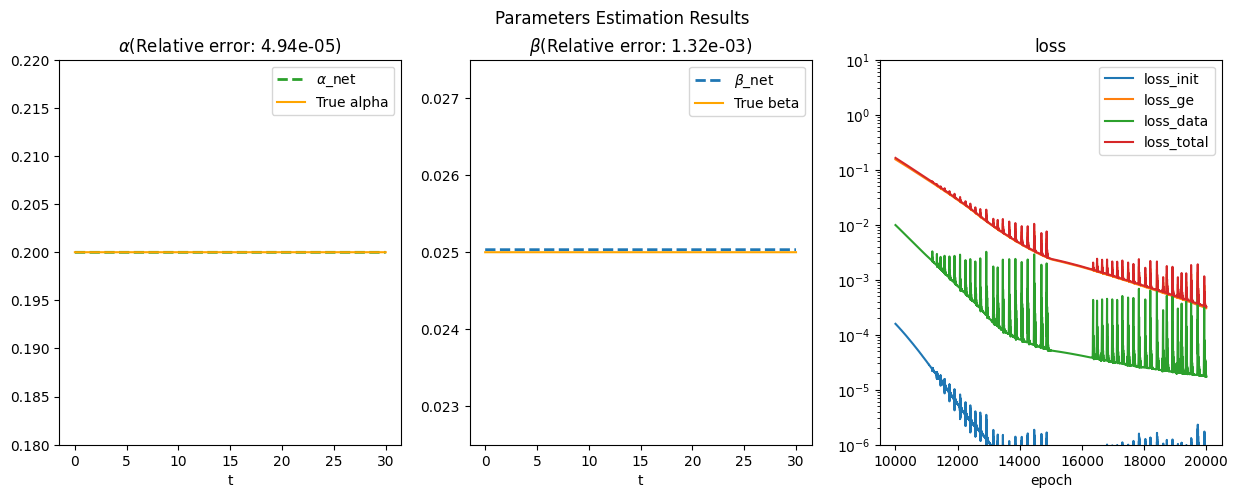

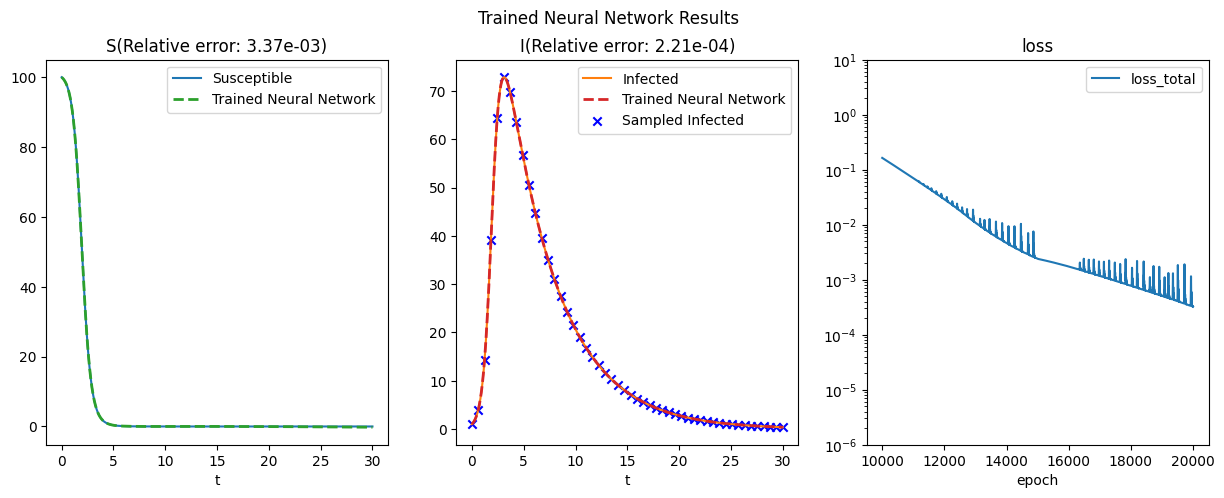

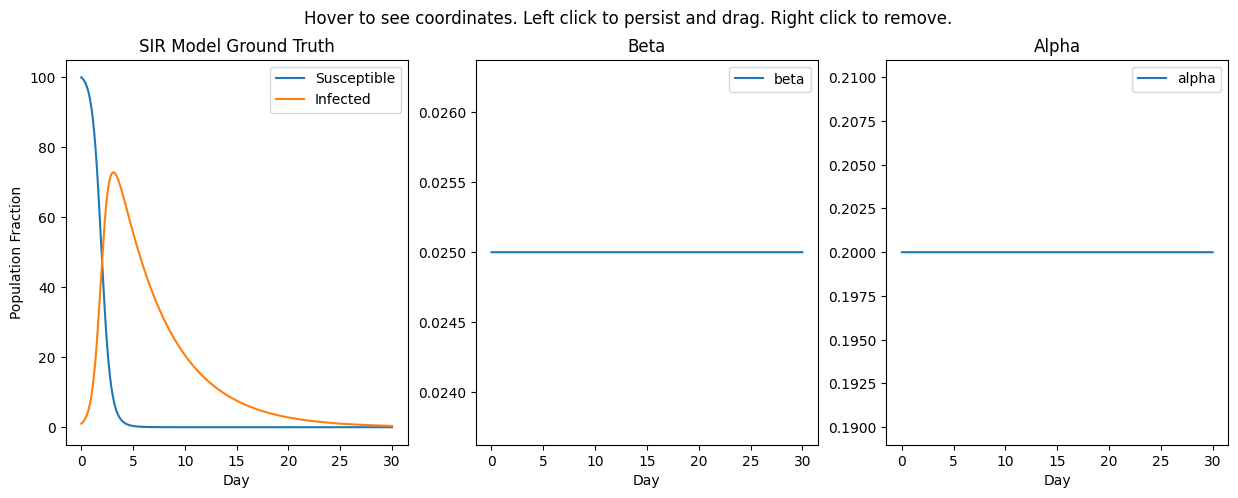

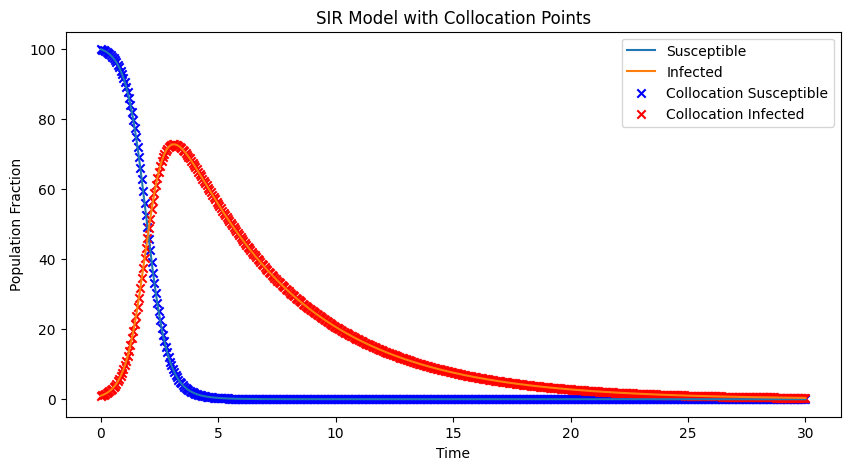

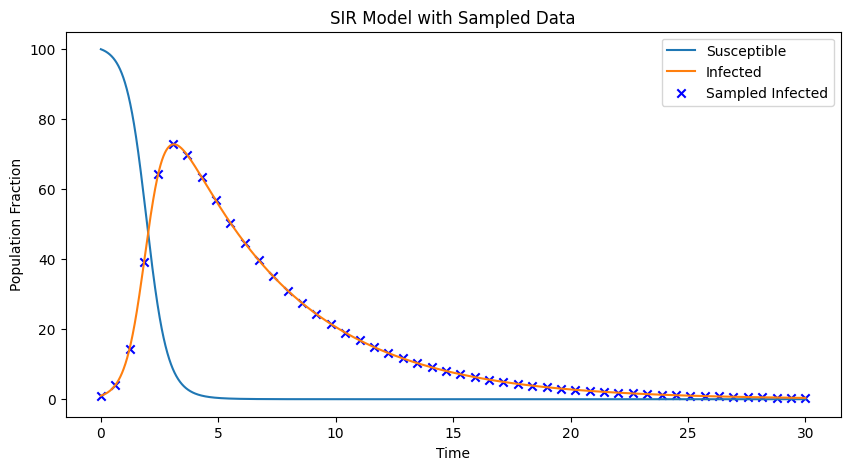

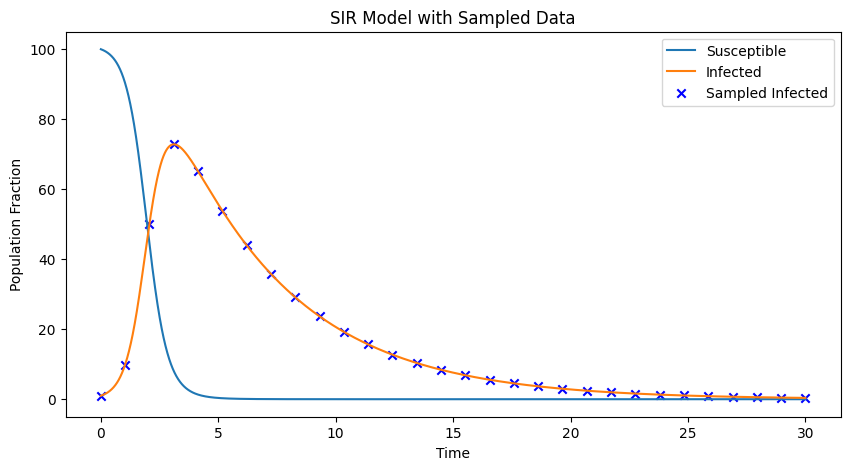

GIF saved at C:\cabbage-leaves/png/20250306010401460775/output.gif
Training Finished.
     Parameter                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     Value
     SIR Model                                                                                                                                                                                                                                                                                                                                                                                           

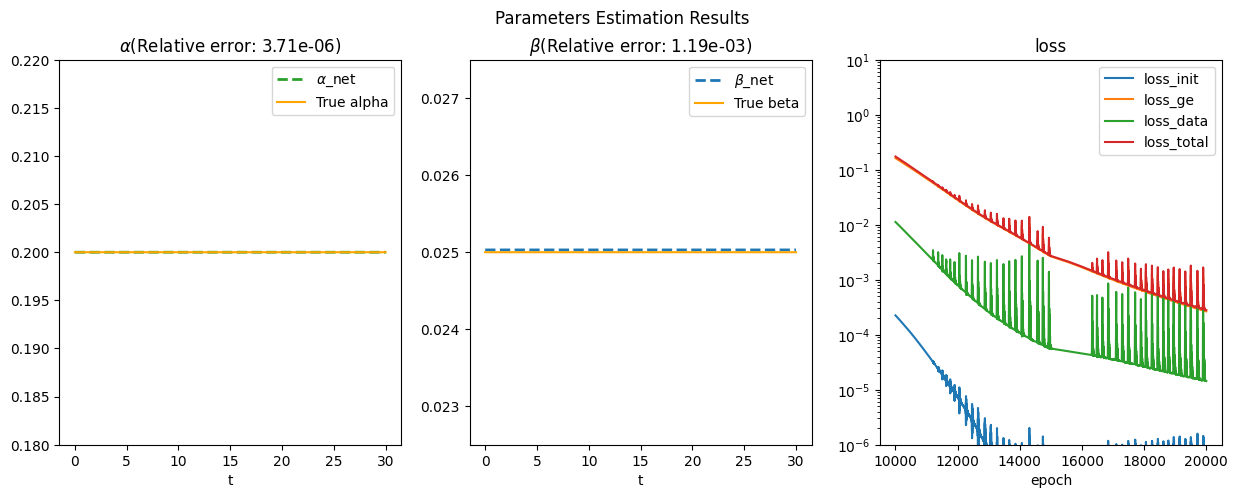

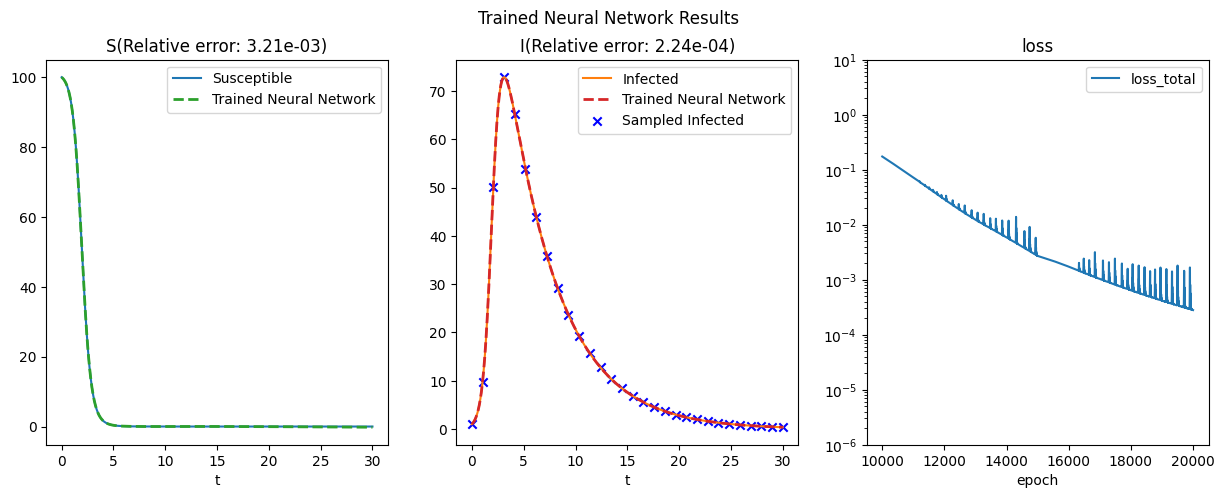

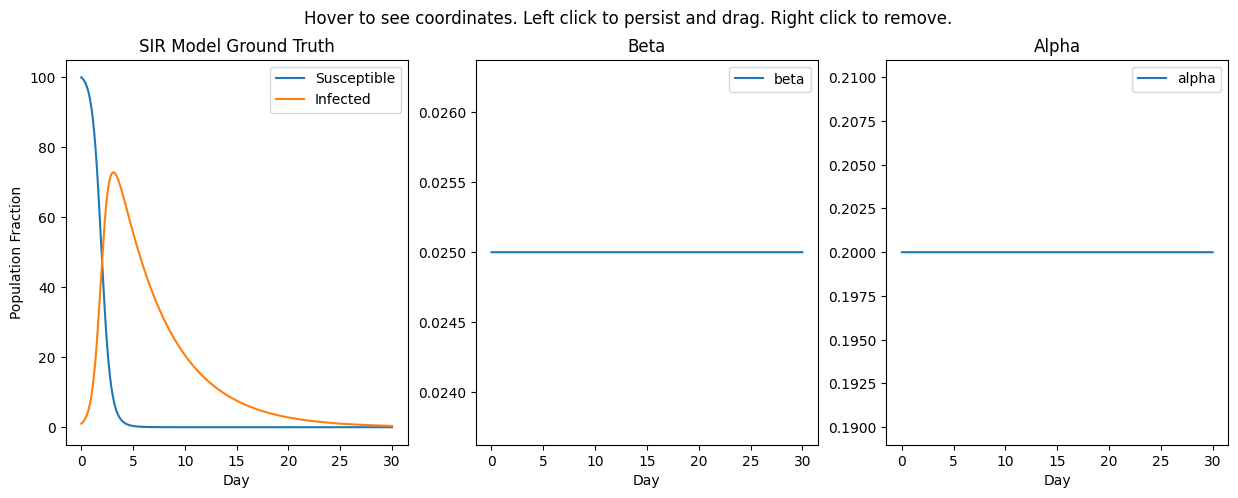

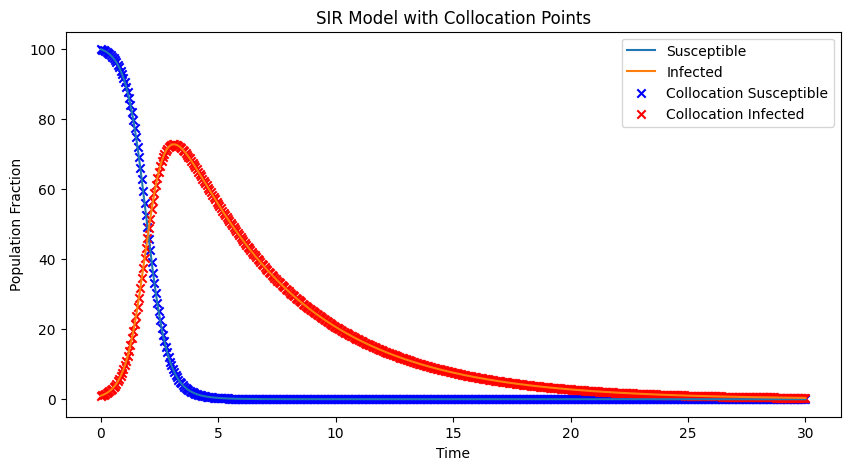

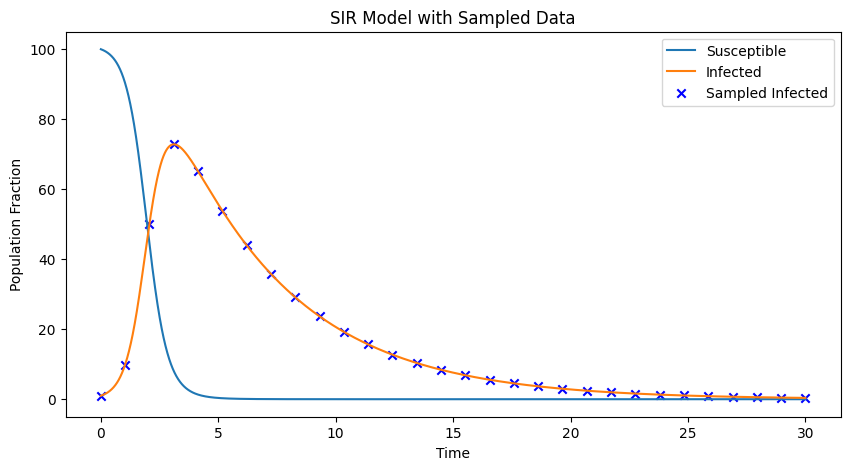

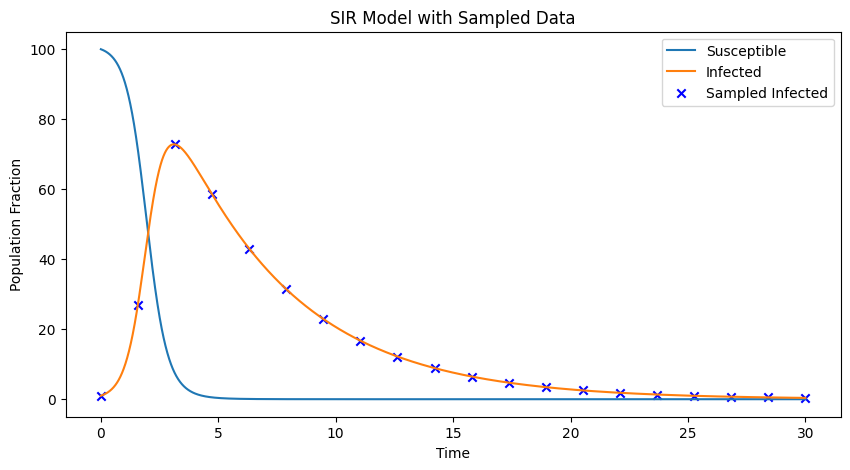

GIF saved at C:\cabbage-leaves/png/20250306010816334809/output.gif
Training Finished.
     Parameter                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     Value
     SIR Model                                                                                                                                                                                                                                                                                                                                                                                           

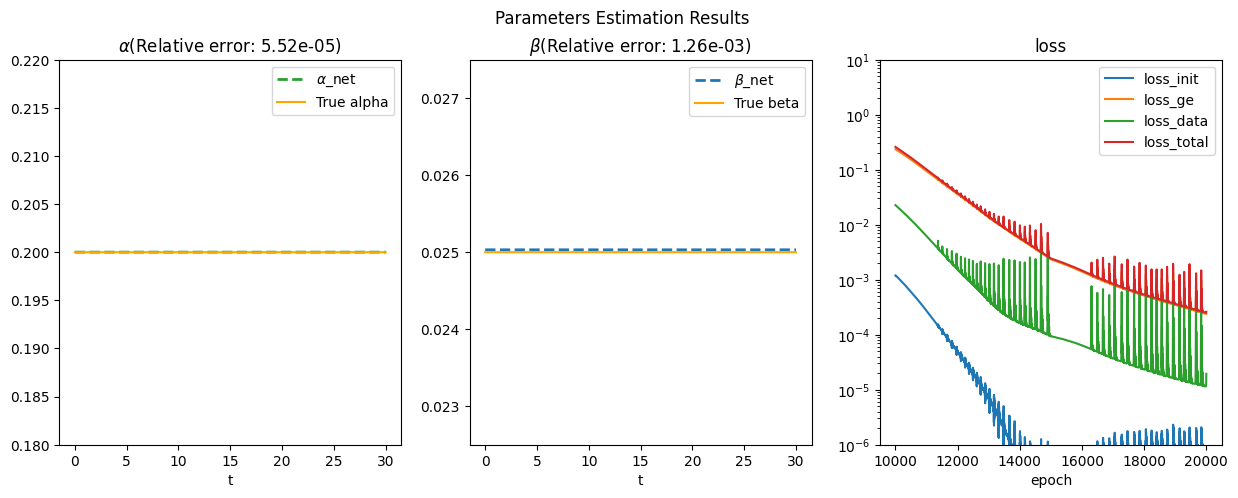

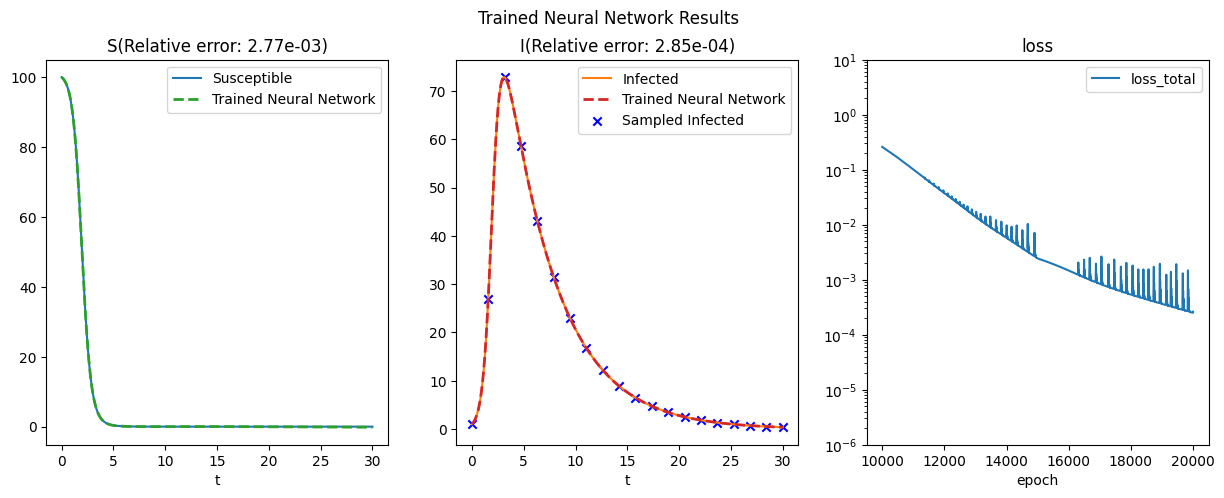

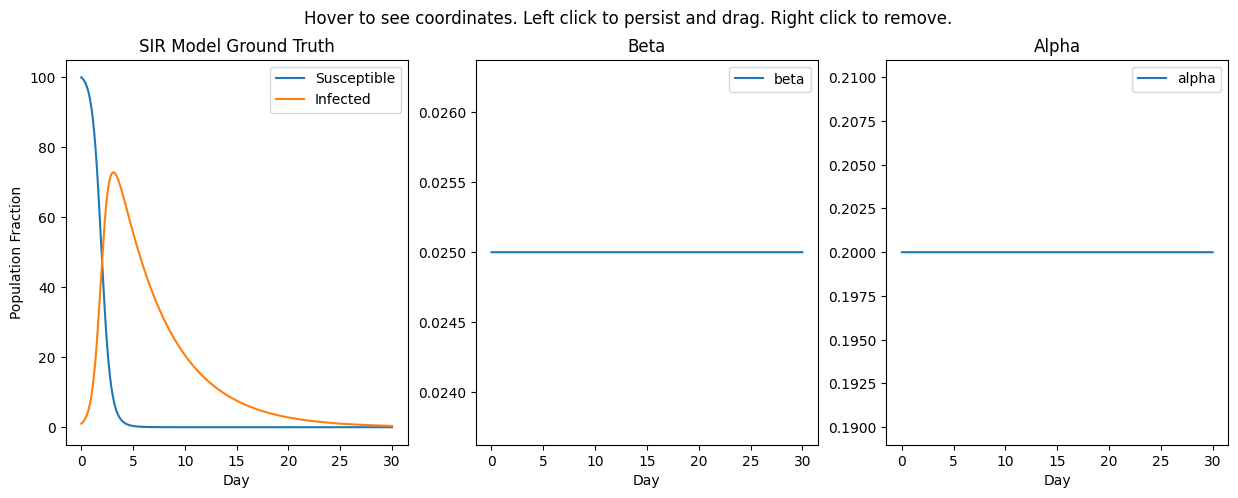

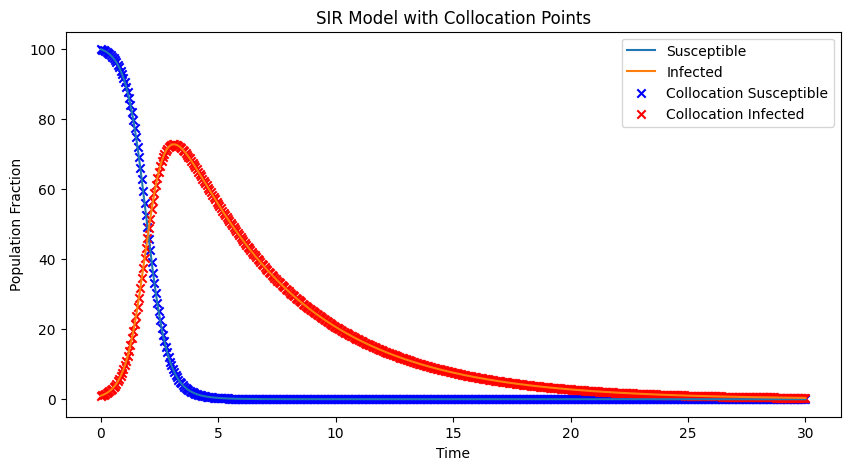

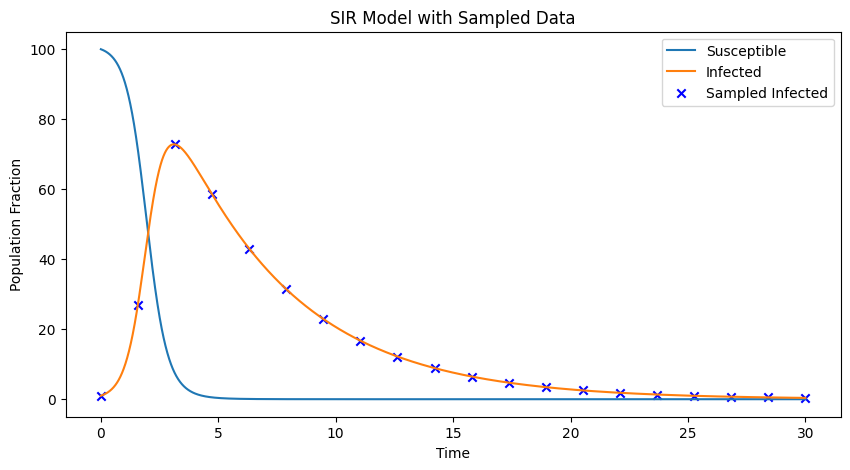

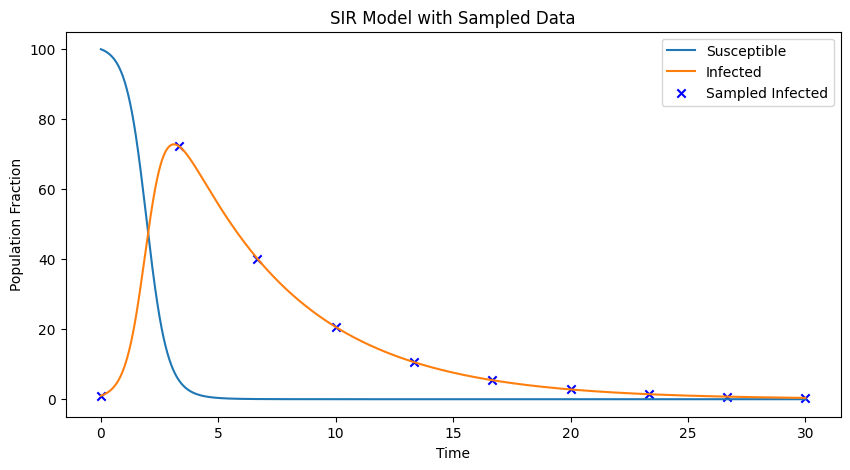

GIF saved at C:\cabbage-leaves/png/20250306011231635885/output.gif
Training Finished.
     Parameter                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     Value
     SIR Model                                                                                                                                                                                                                                                                                                                                                                                           

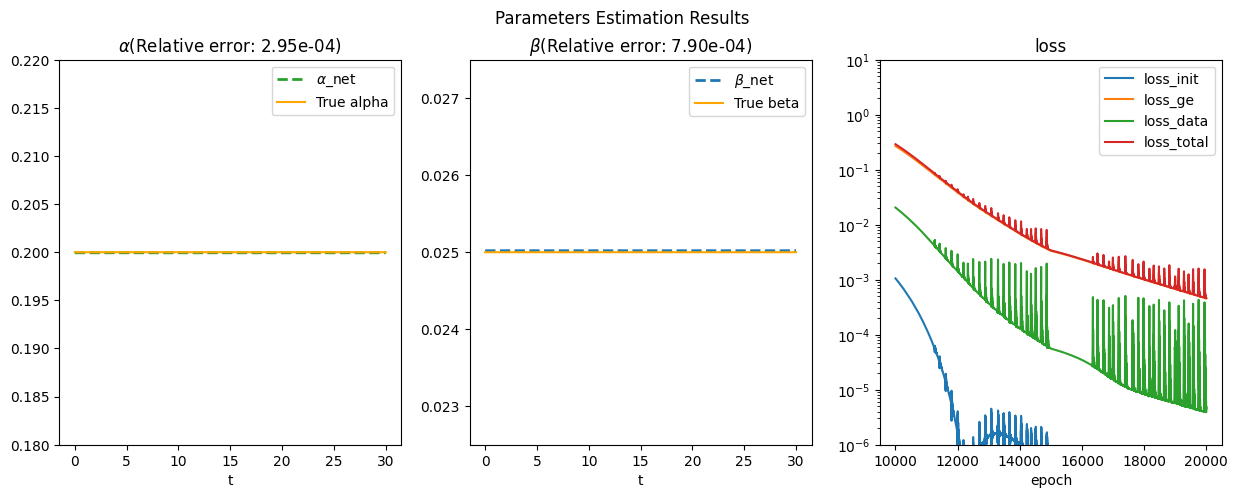

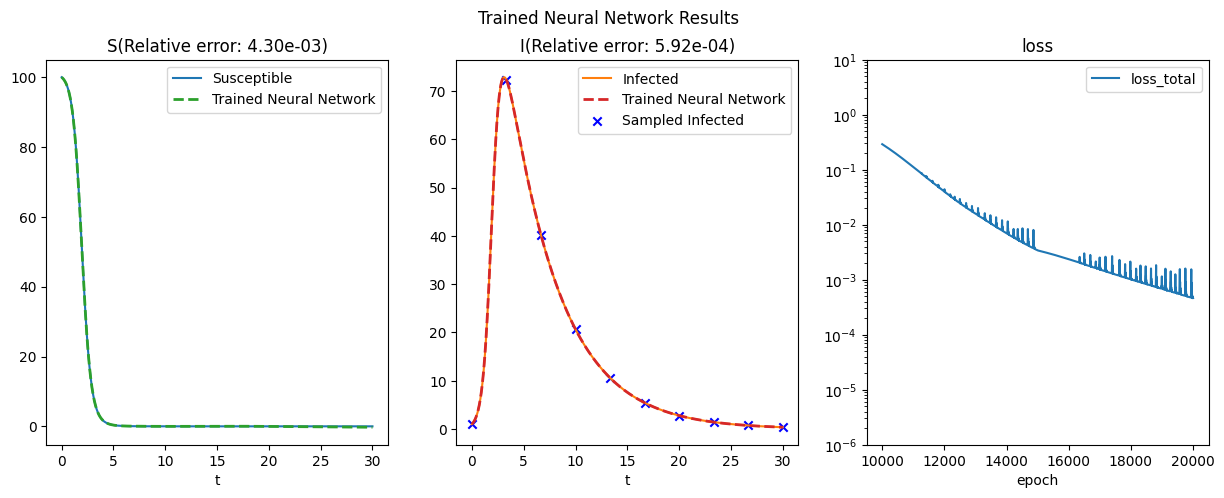

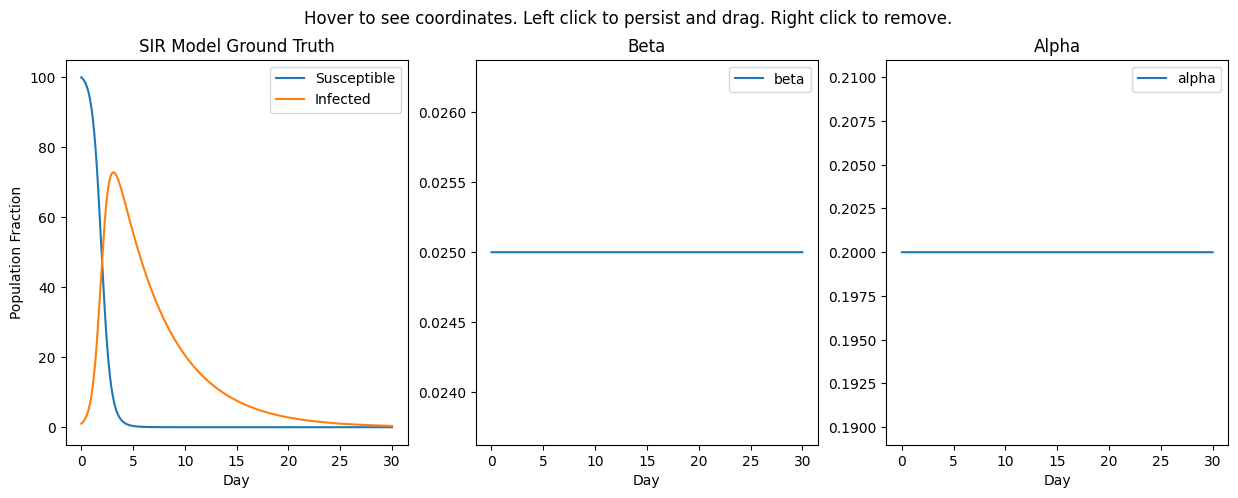

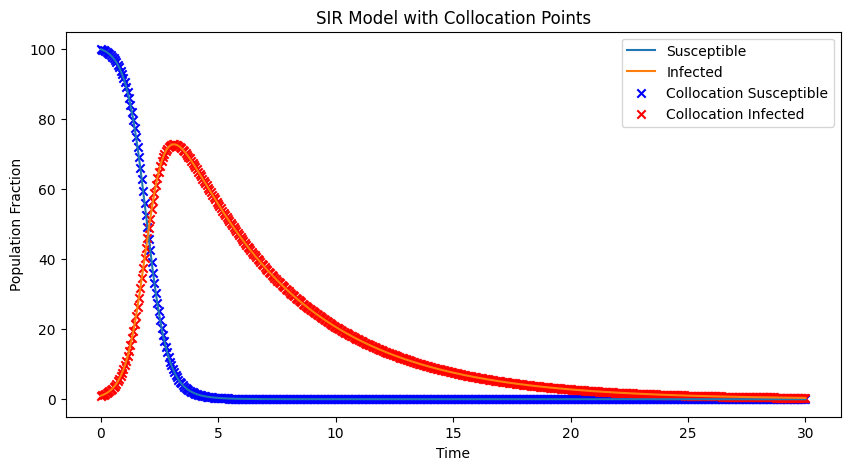

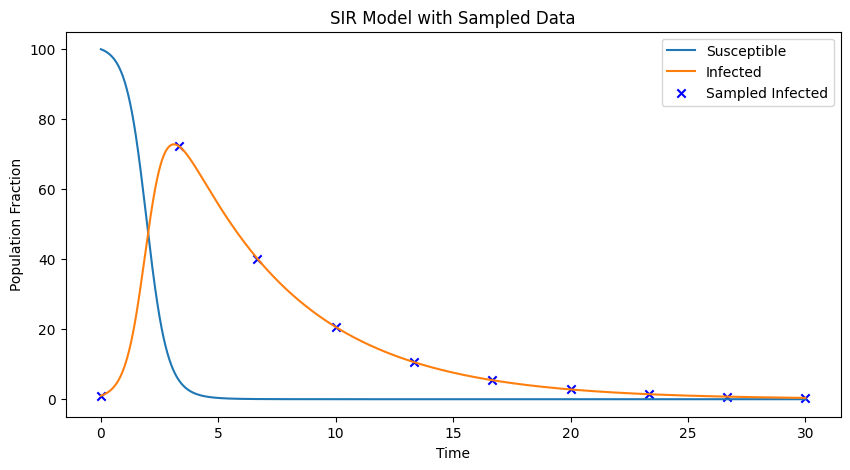

In [85]:
root = 'C:\\cabbage-leaves'

data = SIRModel(0.025, 0.2, 0, 30)
strategy = [
    np.linspace(0, len(data.get_whole_t())-1, 50, dtype=int),
    np.linspace(0, len(data.get_whole_t())-1, 30, dtype=int),
    np.linspace(0, len(data.get_whole_t())-1, 20, dtype=int),
    np.linspace(0, len(data.get_whole_t())-1, 10, dtype=int)
]

init_w = np.ones(20001)
data_w = np.ones(20001)
ge_w = np.ones(20001)

for s in strategy:
    data.set_samples(strategy=s, I_only=True)
    data.set_collocation_points(500)
    data.plot_with_samples()

    network = Model([1,64,64,64,2]).to(device)
    optimizer = optim.Adam(network.parameters(), lr=1e-3)

    ex = Experiment(data, network, optimizer, device, exercise_path=root)
    ex.train_model(visualize=True, loss_weights=(init_w, data_w, ge_w))

    ex.summarize_experiment()
    ex.plot_estimated_parameters()
    ex.plot_trained_NN()
    ex.save_data_image()

## Experiment 4

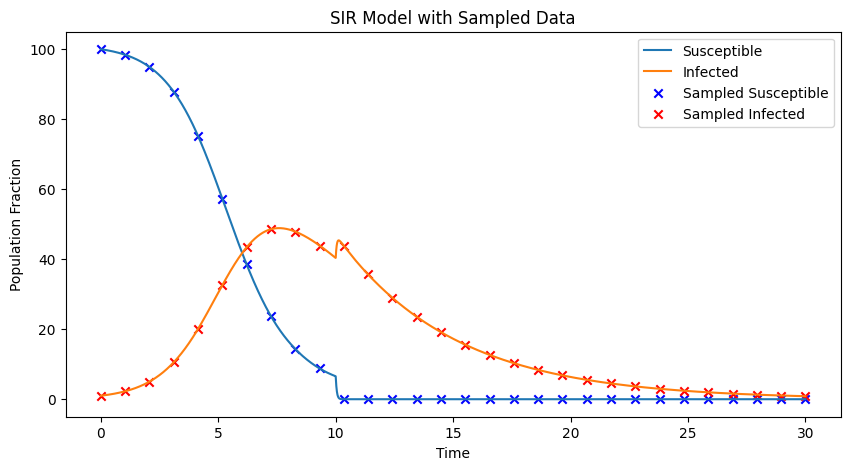

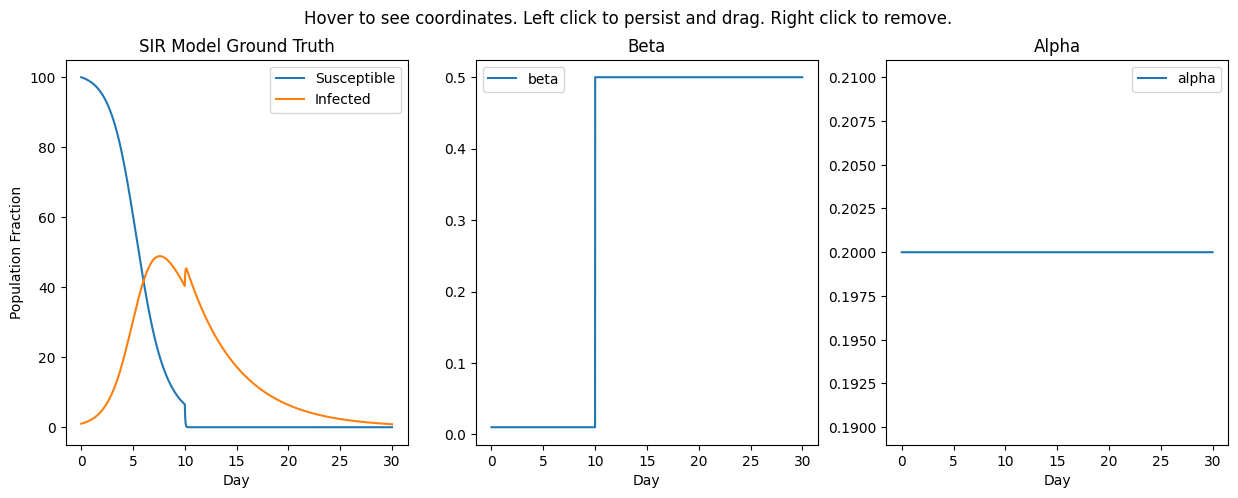

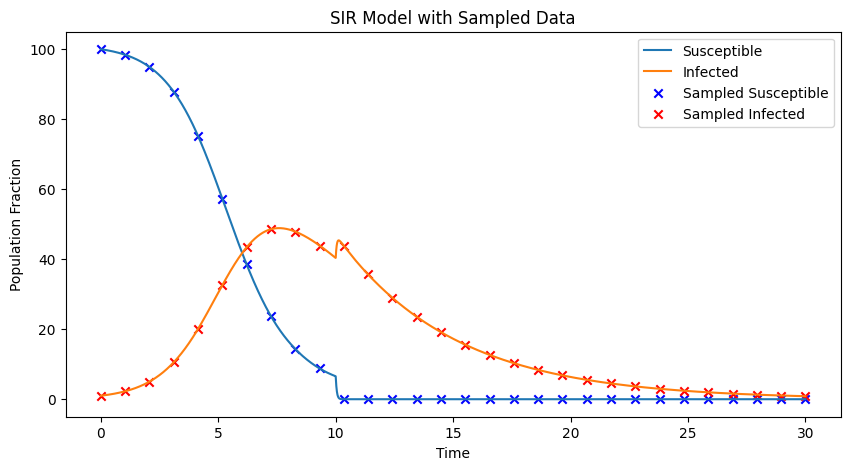

In [18]:
root = 'C:\\cabbage-leaves'

beta = lambda t: np.where(t < 10, 0.01, 0.5)
data = SIRModel(beta, 0.2, 0, 30, 100, 1)
data.set_samples(30, "uniform", I_only=False)
data.set_collocation_points(1000)
data.plot_with_samples()
data.plot_ground_truth()
data.plot_with_samples()

In [19]:
network = Model([1,64,64,64,2], 10).to(device)
optimizer = optim.Adam(network.parameters(), lr=1e-3)

In [20]:
init_w = 0.001*np.ones(20001)
data_w = np.ones(20001)
ge_w = np.logspace(np.log10(0.001), np.log10(1), 20001)
# init_w = np.ones(20001)
# data_w = np.ones(20001)
# ge_w = np.ones(20001)

In [21]:
ex = Experiment(data, network, optimizer, device, exercise_path=root)
ex.train_model(visualize=True, loss_weights=(init_w, data_w, ge_w))

GIF saved at C:\cabbage-leaves/png/20250306122856338223/output.gif
Training Finished.


     Parameter                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

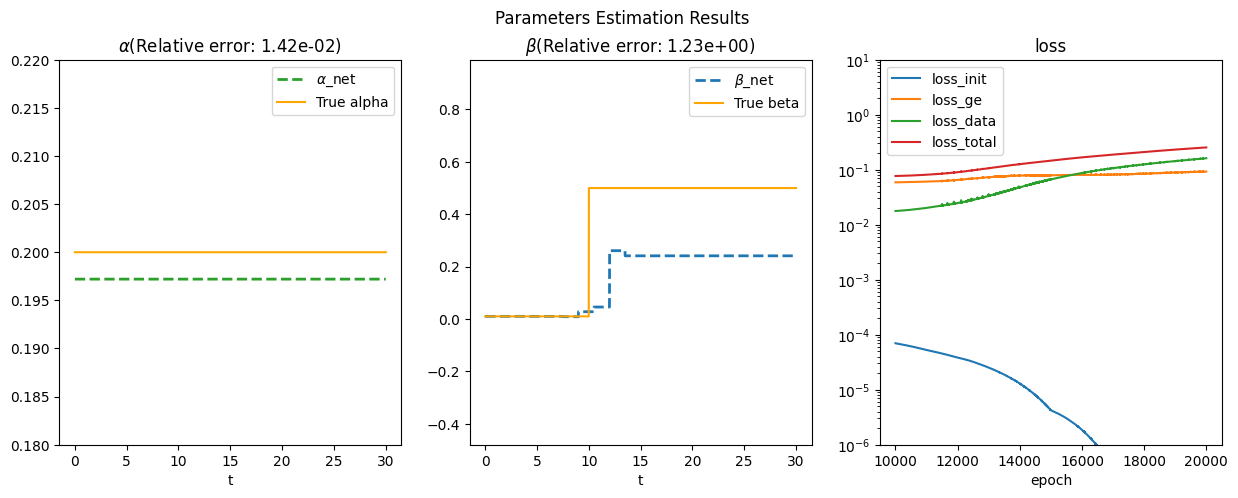

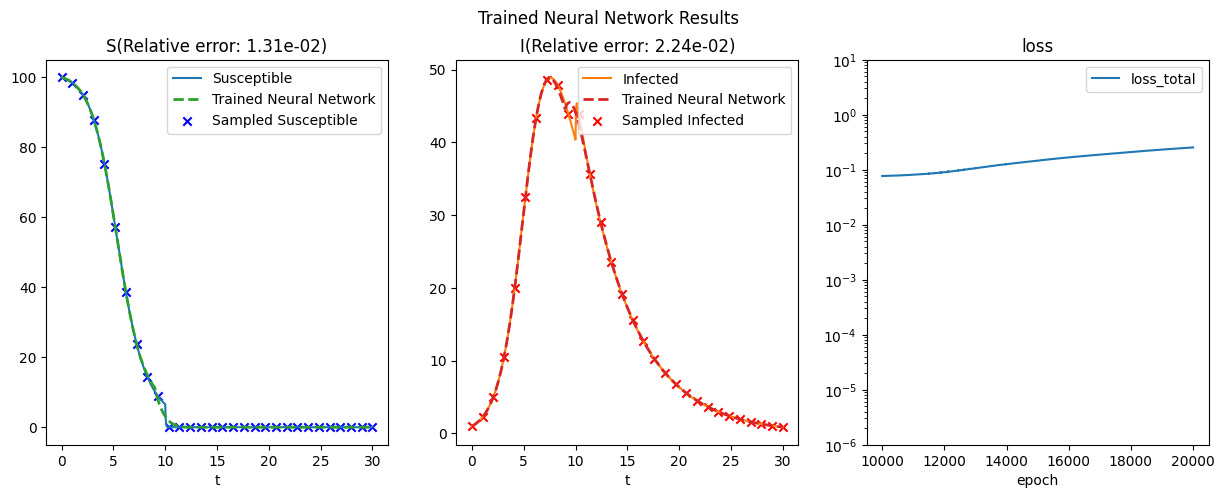

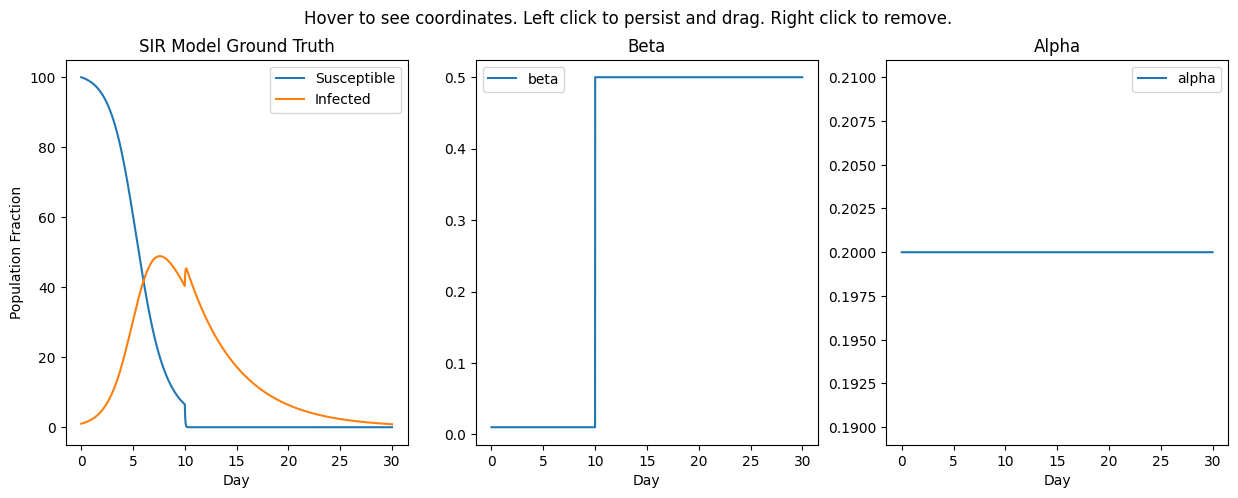

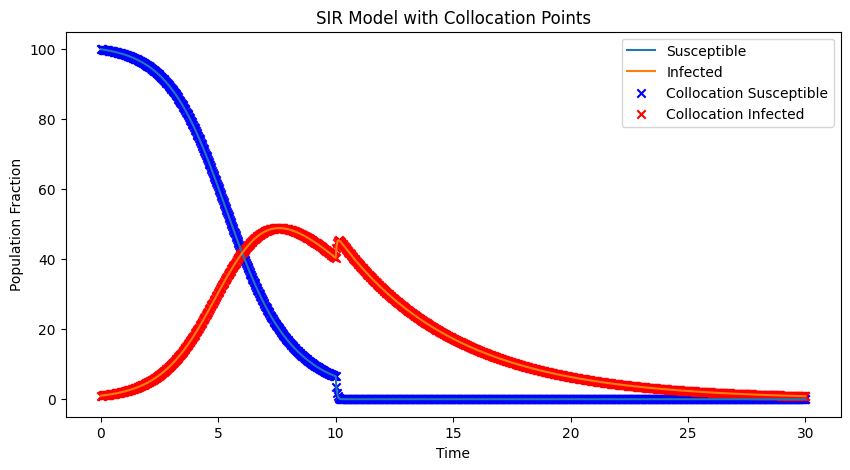

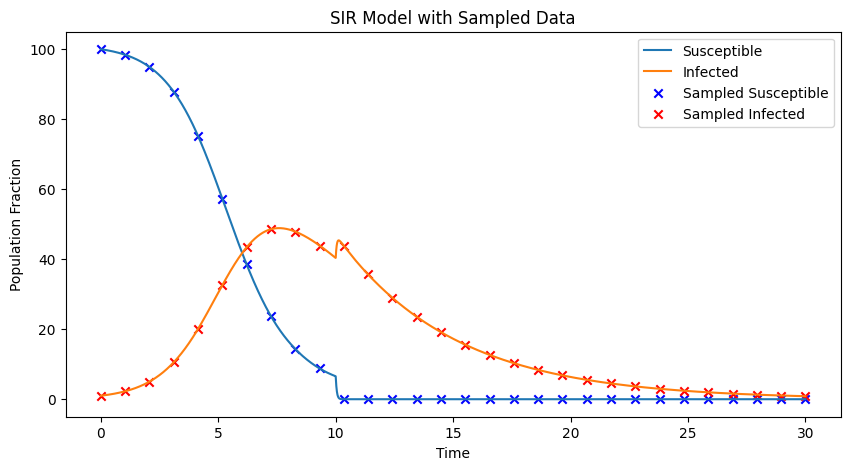

'20250306122856338223'

In [22]:
ex.summarize_experiment()
ex.plot_estimated_parameters()
ex.plot_trained_NN()
ex.save_data_image()
ex.get_serial_folder_name()

## Experiment 5

__main__.SIRModel

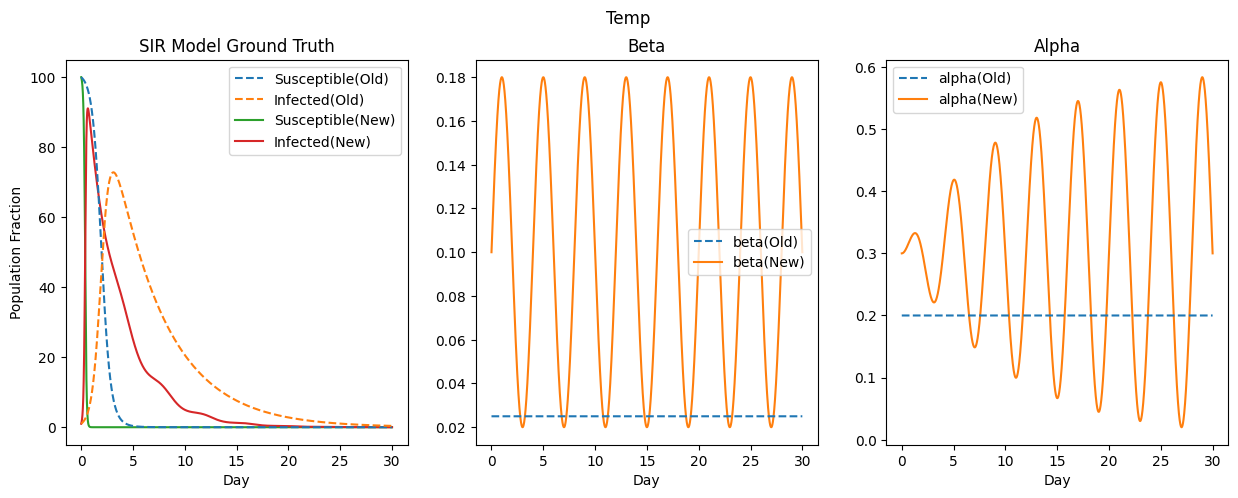

In [ ]:
SIRModel_old = SIRModel(0.025, 0.2, 0, 30)

beta = lambda t: 0.05 * (1 + 0.5 * np.sin(0.1 * t))
beta = lambda t: 0.1 * (1 + 0.8 * np.sin(0.5 * np.pi * t))
alpha = lambda t: 0.1 + 0.2 * (1 - np.exp(-0.05 * t))
alpha = lambda t: 0.3 + 0.3 * (1 - np.exp(-0.1 * t)) * np.sin(0.5 * np.pi * t)
SIRModel_new = SIRModel(beta, alpha, 0, 30)

SIRModel_old.plot_cmp_ground_truth(SIRModel_new)
SIRModel_new.set_collocation_points(500)
SIRModel_new.set_samples()

In [ ]:
network = model([1,64,64,64,2], [1,64,64,64,1], [1,64,64,64,1]).to(device)
optimizer = optim.Adam(network.parameters(), lr=1e-3)

: 

In [ ]:
ex = Experiment(data_class, network, optimizer)
ex.train_model()

Epoch 5600/20000 | Loss_init: 0.0000156 | Loss_ge: 0.0031582 | Loss_data: 0.0031676 | Loss_total: 0.0063413


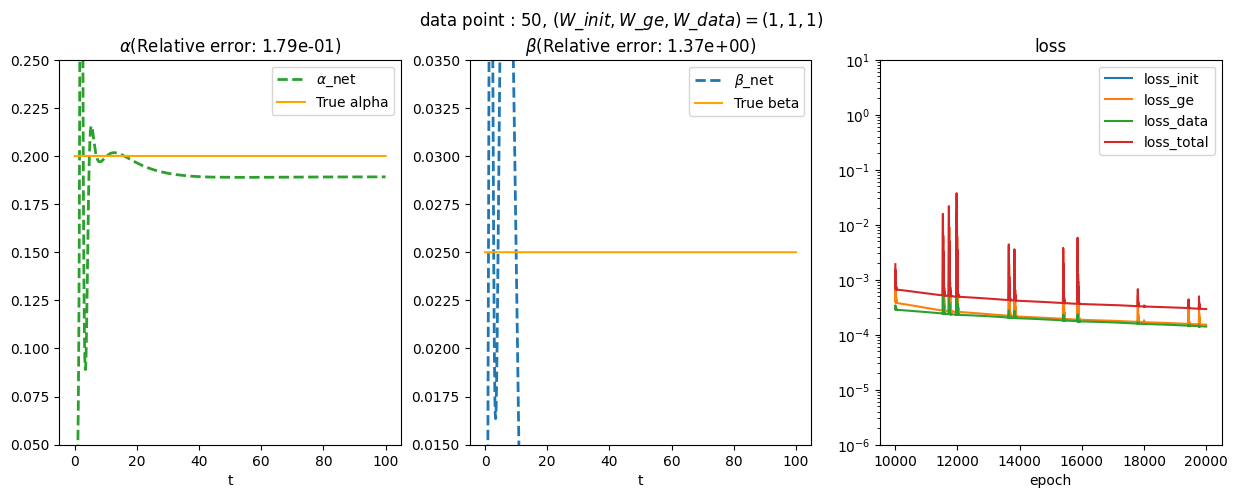

In [397]:
ex.plot_results()